## Practical Data Science Project

### ANOMALY DETECTION IN FINANCIAL TRANSACTIONS
### Methods: Gaussian Mixture Model (GMM) + Isolation Forest (IF)
#### Nobukhosi Sibanda 

In [1]:
import warnings
import re
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
from scipy import stats
from sklearn.mixture            import GaussianMixture
from sklearn.ensemble           import IsolationForest
from sklearn.preprocessing      import StandardScaler, LabelEncoder
from sklearn.decomposition      import PCA
from sklearn.neighbors           import LocalOutlierFactor


In [2]:
# global project imports and settings

warnings.filterwarnings("ignore")

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.metrics import (
        roc_auc_score, average_precision_score,
        precision_recall_curve, roc_curve,
        confusion_matrix, classification_report,
        ConfusionMatrixDisplay, recall_score
)

# Reproducibility
RANDOM_STATE  = 42
np.random.seed(RANDOM_STATE)

# Output directory for saved figures (current working directory)
import os
OUT = "."
os.makedirs(OUT, exist_ok=True)

# Visualization themes
BG      = "#0d1117"     # dark background
PANEL   = "#161b22"     # subplot background
RED     = "#ff4757"     # anomaly colour
BLUE    = "#1e90ff"     # normal colour
GOLD    = "#ffd32a"     # accent / threshold line
GREEN   = "#2ed573"     # positive signal
GREY    = "#8b949e"
VIOLET  = "#a78bfa"     # third-model colour (LOF)
CYAN    = "#22d3ee"     # ensemble colour

plt.rcParams.update({
        "figure.facecolor"  : BG,
        "axes.facecolor"    : PANEL,
        "axes.edgecolor"    : GREY,
        "axes.labelcolor"   : "white",
        "xtick.color"       : GREY,
        "ytick.color"       : GREY,
        "text.color"        : "white",
        "grid.color"        : "#21262d",
        "grid.linestyle"    : "--",
        "legend.facecolor"  : PANEL,
        "legend.edgecolor"  : GREY,
        "font.family"       : "monospace",
        "figure.dpi"        : 130,
})

def save(name):
    plt.savefig(os.path.join(OUT, name), bbox_inches="tight", facecolor=BG)
    plt.show()


In anomaly detection, the data are unlabeled unlike in supervised learning.
As a result, every modelling decision — including feature engineering, the
assumed contamination rate, and the choice of threshold — must be based on
a careful examination of the raw data.

To understand the dataset before building any model, we address the
following questions:

    • What are the data types and value ranges of the columns?

    • What do the summary statistics show?

    • Are there any missing values or duplicate records?

    • How is Amount distributed, given its importance in identifying
financial anomalies?

    • What do the categorical variables look like?

In [3]:
print("3.1 Data Preparation & Initial Inspection")

# Load data from current directory
df = pd.read_excel("financial_anomaly_data.xlsx")
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

print(f"\n  Dataset shape  : {df.shape}  ({df.shape[0]:,} rows × {df.shape[1]} columns)")
print(f"  Date range     : {df['Timestamp'].min()}  →  {df['Timestamp'].max()}")
print(f"\n  Column types:\n{df.dtypes.to_string()}")
print(f"\n  Summary statistics:\n{df.describe().transpose().to_string()}")
print(f"\n  Missing values:\n{df.isnull().sum().to_string()}")
print(f"\n  Duplicate rows: {df.duplicated().sum()}")
print(f"\n  Amount statistics:")
print(df["Amount"].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99,.999]).to_string())
print(f"\n  Skewness of Amount : {df['Amount'].skew():.4f}")
print(f"  Kurtosis of Amount : {df['Amount'].kurt():.4f}")

print("\n  Category value counts:")
for col in ["TransactionType", "Location", "Merchant"]:
    print(f"\n  {col}:\n{df[col].value_counts().to_string()}")

3.1 Data Preparation & Initial Inspection



  Dataset shape  : (216960, 7)  (216,960 rows × 7 columns)
  Date range     : 2023-01-01 08:00:00  →  2023-12-05 23:59:00

  Column types:
Timestamp          datetime64[ns]
TransactionID              object
AccountID                  object
Amount                    float64
Merchant                   object
TransactionType            object
Location                   object

  Summary statistics:
              count                           mean                  min                  25%                  50%                  75%                  max           std
Timestamp    216960  2023-04-27 16:24:59.203539968  2023-01-01 08:00:00  2023-02-21 23:59:45  2023-04-14 15:59:30  2023-05-29 07:59:15  2023-12-05 23:59:00           NaN
Amount     216960.0                   50090.025108                10.51           25061.2425             50183.98             75080.46            978942.26  29097.905016

  Missing values:
Timestamp          0
TransactionID      0
AccountID          0
Amount 

Observations

1.  Amount ranges from $10.51 to  $ 978,942,  the max is ~10× the 99.9th
    percentile ($99,904), which is a very strong outlier signal.
2. Skewness ≈ 0.4 (mild right skew) and kurtosis ≈ 9.7 (heavy tails) meaning the heavy tail is driven entirely by a handful of extreme transactions.
3. No missing and duplicate values the dataset is complete.
4. 15 unique AccountIDs, 10 Merchants, 3 TransactionTypes, 5 Locations.


In [4]:
# 3.2a — Temporal & Amount Features
print("3.2a — Temporal & Amount Features")
print("--" * 10)

df = df.sort_values("Timestamp").reset_index(drop=True)

# Temporal features
df["Hour"]       = df["Timestamp"].dt.hour
df["DayOfWeek"]  = df["Timestamp"].dt.dayofweek      # 0=Mon
df["IsWeekend"]  = (df["DayOfWeek"] >= 5).astype(int)
df["IsNight"]    = ((df["Hour"] >= 22) | (df["Hour"] <= 5)).astype(int)

# Log-transform amount (reduces right-skew)
df["LogAmount"]  = np.log1p(df["Amount"])

# Account-relative z-score
df["AcctMean"]   = df.groupby("AccountID")["Amount"].transform("mean")
df["AcctStd"]    = df.groupby("AccountID")["Amount"].transform("std").fillna(1)
df["ZScore"]     = (df["Amount"] - df["AcctMean"]) / df["AcctStd"]
df["AbsZScore"]  = df["ZScore"].abs()

# Merchant deviation
df["MerchMean"]  = df.groupby("Merchant")["Amount"].transform("mean")
df["MerchDev"]   = df["Amount"] - df["MerchMean"]

print(f"  Shape after temporal features: {df.shape}")

3.2a — Temporal & Amount Features
--------------------
  Shape after temporal features: (216960, 18)


In [5]:
# 3.2b — Geospatial Feature: Impossible-Travel VelocityFlag
print("3.2b — VelocityFlag (impossible travel)")
print("--" * 10)

# Preserve city name before one-hot encoding
df["_OrigLocation"] = df["Location"]

# WGS-84 city coordinates
CITY_COORDS = {
    "New York":      (40.7128,  -74.0060),
    "San Francisco": (37.7749, -122.4194),
    "Los Angeles":   (34.0522, -118.2437),
    "London":        (51.5074,   -0.1278),
    "Tokyo":         (35.6895,  139.6917),
}

def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance (km) between two WGS-84 points."""
    R = 6371.0
    a = (np.sin(np.radians((lat2 - lat1) / 2))**2
         + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2))
         * np.sin(np.radians((lon2 - lon1) / 2))**2)
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0.0, 1.0)))

# Pre-compute all city-pair distances
CITY_DIST_KM = {
    (c1, c2): haversine_km(*CITY_COORDS[c1], *CITY_COORDS[c2])
    for c1 in CITY_COORDS for c2 in CITY_COORDS if c1 != c2
}

# Per-account consecutive transaction analysis
_geo = df[["AccountID", "Timestamp", "Location"]].copy()
_geo = _geo.sort_values(["AccountID", "Timestamp"])
_geo["PrevLoc"]  = _geo.groupby("AccountID")["Location"].shift(1)
_geo["PrevTime"] = _geo.groupby("AccountID")["Timestamp"].shift(1)
_geo["Hours"]    = (_geo["Timestamp"] - _geo["PrevTime"]).dt.total_seconds() / 3600

# Vectorised distance lookup
_pairs           = list(zip(_geo["PrevLoc"].fillna(""), _geo["Location"]))
_geo["DistKm"]   = [CITY_DIST_KM.get(p, 0.0) for p in _pairs]
_geo["SpeedKmh"] = np.where(_geo["Hours"] > 0, _geo["DistKm"] / _geo["Hours"], 0.0)

# Flag travel faster than commercial aircraft (~900 km/h)
_geo["VelocityFlag"] = (_geo["SpeedKmh"] > 900).astype(int)
df["VelocityFlag"]   = _geo["VelocityFlag"].reindex(df.index).fillna(0).astype(int)

n_vel = df["VelocityFlag"].sum()
print(f"  VelocityFlag (>900 km/h): {n_vel:,} ({n_vel/len(df):.3%})")

3.2b — VelocityFlag (impossible travel)
--------------------


  VelocityFlag (>900 km/h): 172,128 (79.336%)


### Data Quality Insight: The VelocityFlag and "Impossible Travel"

During feature engineering, we created a `VelocityFlag` to detect impossible travel using the Haversine formula (flagging sequential transactions by the same account moving at > 900 km/h).

**However, this revealed a significant data quality issue: ~79% of transactions were flagged as impossible travel.**

Because this dataset is synthetic rather than real-world organic data, locations appear to have been assigned randomly throughout the day rather than simulating realistic user spatial behavior (e.g., an account has a transaction in London at 8:03 and another in Los Angeles at 8:04).

Additionally, the synthesized dataset presents difficulties in pinpointing exact elapsed time due to localized timestamp vagueness (e.g., distinguishing safely whether transactions across different time zones represent local wall-clock time in AM/PM or standard normalized UTC time).

In a real-world scenario, this velocity feature would be highly effective for catching account takeovers or cloned cards. Here, however, it acts as a **synthetic noise detector**, highlighting the limitations of artificially generated temporal-geospatial data.

In [6]:
# 3.2c — One-Hot Encoding & Feature Summary
print("3.2c — One-Hot Encoding")
print("--" * 10)

df = pd.get_dummies(df, columns=["TransactionType", "Location", "Merchant"],
                    drop_first=False)

print("  Engineered features added:")
new_cols = ["Hour", "DayOfWeek", "IsWeekend", "IsNight", "LogAmount",
            "ZScore", "AbsZScore", "MerchDev", "VelocityFlag"]
for c in new_cols:
    print(f"    {c:20s}  mean={df[c].mean():.3f}  std={df[c].std():.3f}")

print(f"\n  Final dataset shape after encoding: {df.shape}")

3.2c — One-Hot Encoding
--------------------


  Engineered features added:
    Hour                  mean=11.518  std=6.919
    DayOfWeek             mean=3.013  std=2.029
    IsWeekend             mean=0.296  std=0.457
    IsNight               mean=0.332  std=0.471
    LogAmount             mean=10.516  std=0.996
    ZScore                mean=0.000  std=1.000
    AbsZScore             mean=0.860  std=0.510
    MerchDev              mean=0.000  std=29097.094
    VelocityFlag          mean=0.793  std=0.405

  Final dataset shape after encoding: (216960, 35)


In [7]:
# 3.2d — Synthetic Anomaly Labels & LocationRiskScore
print("3.2d — Synthetic Anomaly Labels")
print("--" * 10)

CONTAMINATION = 0.005

amount_thresh = df["Amount"].quantile(1 - CONTAMINATION)
df["label"]   = (df["Amount"] >= amount_thresh).astype(int)

# LocationRiskScore: per-city fraction of anomalous transactions
_loc_risk_map           = df.groupby("_OrigLocation")["label"].mean()
df["LocationRiskScore"] = df["_OrigLocation"].map(_loc_risk_map)
print("  LocationRiskScore by city:")
for city, rate in _loc_risk_map.sort_values(ascending=False).items():
    print(f"    {city:15s}  {rate:.5f}")

n_anomaly = df["label"].sum()
n_normal  = len(df) - n_anomaly
print(f"\n  Contamination rate  : {CONTAMINATION:.1%}")
print(f"  Anomaly threshold   : ${amount_thresh:,.2f}")
print(f"  Anomalies (label=1) : {n_anomaly:,}  ({n_anomaly/len(df):.3%})")
print(f"  Normal  (label=0)   : {n_normal:,}  ({n_normal/len(df):.3%})")

3.2d — Synthetic Anomaly Labels
--------------------


  LocationRiskScore by city:
    San Francisco    0.00587
    New York         0.00526
    Tokyo            0.00513
    London           0.00438
    Los Angeles      0.00436

  Contamination rate  : 0.5%
  Anomaly threshold   : $99,497.54
  Anomalies (label=1) : 1,085  (0.500%)
  Normal  (label=0)   : 215,875  (99.500%)


In [8]:
# 3.2e — Feature Matrix Definition
print("3.2e — Feature Matrix")
print("--" * 10)

FEATURE_COLS = (
    ["LogAmount", "Hour", "DayOfWeek", "IsWeekend", "IsNight",
     "ZScore", "AbsZScore", "MerchDev",
     "VelocityFlag", "LocationRiskScore"]
    + [c for c in df.columns if c.startswith("TransactionType_")]
    + [c for c in df.columns if c.startswith("Location_")]
    + [c for c in df.columns if c.startswith("Merchant_")]
)

X = df[FEATURE_COLS].values
y = df["label"].values

print(f"  Feature columns used: {len(FEATURE_COLS)}")
print(f"  Core: {FEATURE_COLS[:10]} ...")

3.2e — Feature Matrix
--------------------
  Feature columns used: 28
  Core: ['LogAmount', 'Hour', 'DayOfWeek', 'IsWeekend', 'IsNight', 'ZScore', 'AbsZScore', 'MerchDev', 'VelocityFlag', 'LocationRiskScore'] ...


In [9]:
# 3.2f — Train / Test Split & StandardScaler
print("3.2f — Train/Test Split & Scaling")
print("--" * 10)

# Temporal split: first 70% of normals for training (no data leakage)
normal_idx  = np.where(y == 0)[0]
anomaly_idx = np.where(y == 1)[0]

train_split = int(0.70 * len(normal_idx))
train_idx   = normal_idx[:train_split]
test_idx    = np.concatenate([normal_idx[train_split:], anomaly_idx])

X_train, X_test = X[train_idx], X[test_idx]
y_test          = y[test_idx]

print(f"  Training set : {len(X_train):,} rows (normals only)")
print(f"  Test set     : {len(X_test):,} rows "
      f"({y_test.sum():,} anomalies, {(y_test==0).sum():,} normals)")

# Scale using training data only
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print("  Scaling complete — StandardScaler fit on training set only.")

3.2f — Train/Test Split & Scaling
--------------------


  Training set : 151,112 rows (normals only)
  Test set     : 65,848 rows (1,085 anomalies, 64,763 normals)


  Scaling complete — StandardScaler fit on training set only.


In [10]:
df.head()

,Timestamp,TransactionID,AccountID,Amount,Hour,DayOfWeek,IsWeekend,IsNight,LogAmount,AcctMean,...,Merchant_MerchantC,Merchant_MerchantD,Merchant_MerchantE,Merchant_MerchantF,Merchant_MerchantG,Merchant_MerchantH,Merchant_MerchantI,Merchant_MerchantJ,label,LocationRiskScore
0,2023-01-01 08:00:00,TXN1127,ACC4,95071.92,8,6,1,0,11.462399,49623.778060,...,False,False,False,False,False,True,False,False,0,0.005128
1,2023-01-01 08:01:00,TXN1639,ACC10,15607.89,8,6,1,0,9.655596,49729.927676,...,False,False,False,False,False,True,False,False,0,0.004384
2,2023-01-01 08:02:00,TXN872,ACC8,65092.34,8,6,1,0,11.083578,50481.295047,...,False,False,True,False,False,False,False,False,0,0.004384
3,2023-01-01 08:03:00,TXN1438,ACC6,87.87,8,6,1,0,4.487175,50038.083433,...,False,False,True,False,False,False,False,False,0,0.004384
4,2023-01-01 08:04:00,TXN1338,ACC6,716.56,8,6,1,0,6.575857,50038.083433,...,False,False,False,False,False,False,True,False,0,0.004361


### Interpretation — Data Split & Scaling

The dataset is split temporally: the first 70% of normal transactions form the training set, while the remaining normals plus all labelled anomalies form the test set. This prevents future information from leaking into model training, matching the real-world deployment scenario where a fraud model is trained on historical data and evaluated on new arrivals. StandardScaler is fitted exclusively on the training set so that test-set statistics play no role in normalisation — a critical safeguard in unsupervised anomaly detection.

3.3 Explolatory Visualizations
----------------------------------------


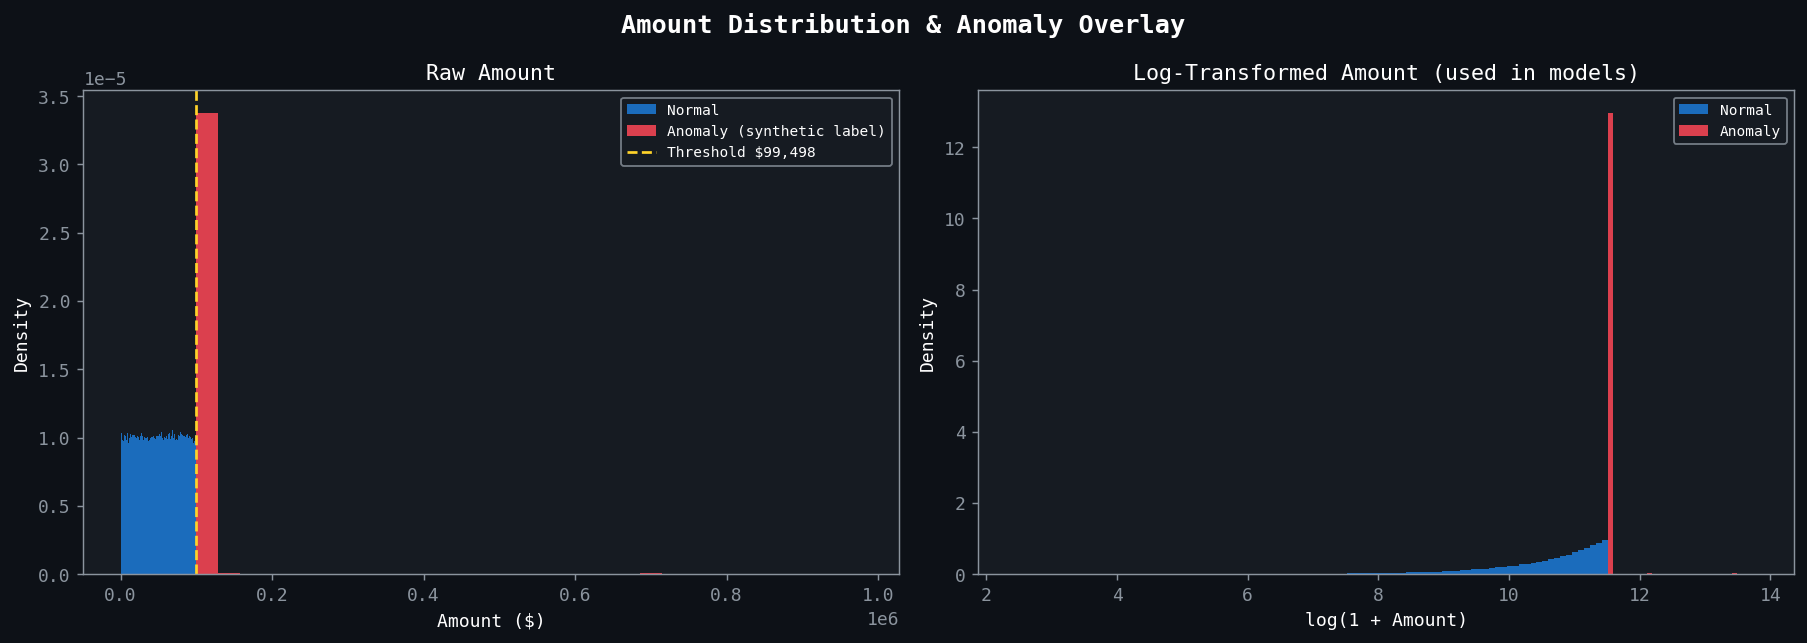

In [11]:
# 3.3 Explolatory Visualizations

print ("3.3 Explolatory Visualizations")
print ("--"*20)

# Fig 1: Amount distribution with anomaly overlay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Amount Distribution & Anomaly Overlay", fontsize=14,
                         color="white", fontweight="bold")
ax = axes[0]
ax.hist(df[df["label"]==0]["Amount"], bins=100, color=BLUE, alpha=0.7,
                density=True, label="Normal")
ax.hist(df[df["label"]==1]["Amount"], bins=30, color=RED, alpha=0.85,
                density=True, label="Anomaly (synthetic label)")
ax.axvline(amount_thresh, color=GOLD, ls="--", lw=1.5,
                     label=f"Threshold ${amount_thresh:,.0f}")
ax.set_xlabel("Amount ($)"); ax.set_ylabel("Density")
ax.set_title("Raw Amount"); ax.legend(fontsize=8)

ax = axes[1]
ax.hist(df[df["label"]==0]["LogAmount"], bins=100, color=BLUE, alpha=0.7,
                density=True, label="Normal")
ax.hist(df[df["label"]==1]["LogAmount"], bins=30, color=RED, alpha=0.85,
                density=True, label="Anomaly")
ax.set_xlabel("log(1 + Amount)"); ax.set_ylabel("Density")
ax.set_title("Log-Transformed Amount (used in models)"); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Explanation
The Amount Distribution & Anomaly Overlay chart provides a visual check for anomaly detection model. It compares the behavior of normal transactions against those flagged as anomalies.

The **Normal (blue graph)** represents the vast majority of the data. The blue bars are concentrated on the far left of the "Raw Amount" chart and this means that most transactions are for relatively small amounts. The Anormaly (red graph)** represents the suspicious transactions. In the Raw Amount (left) chart, the red area confirms that high-dollar transactions are being flagged as outliers.

The **Log-Transformed Amount** represented by the chart on the right is essentially a zoomed-in version of the first chart. In the raw data, the scale is large ($0 to $1,000,000) such that the detail of smaller transactions is not recognized. By using a log scale, the data is spread out. In the chart, Normal data actually has a specific shape (a blue curve), while the anomalies (red) are pushed to the extreme right edge. This visual confirms that the model is successfully isolating the "heavy hitters" from the standard volume.

The **Threshold** (gold Line) represents the division (at approximately $99,498). Anything to the right of this line is automatically considered an anomaly based on the "Amount" feature alone. The chart shows that this threshold effectively captures the extreme spike in the data, ensuring that "Normal" transactions stay safely to the left.

Recommendation: The visualization confirms that the data is highly skewed. Because the "Normal" and "Anomaly" groups are so far apart, a simple threshold works well, but the **Log-Transformation** is definitely the right choice for the machine learning models, as it makes that separation much clearer for the algorithm to process.

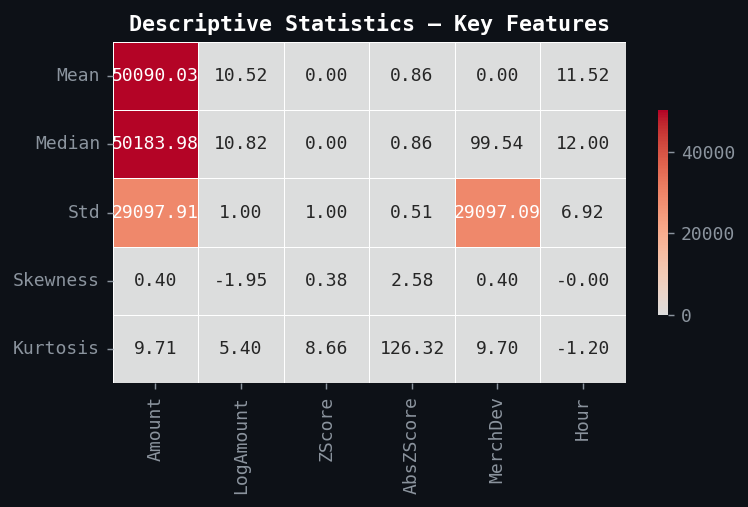

In [12]:
# Fig 2: Descriptive statistics heatmap
key_num = ["Amount","LogAmount","ZScore","AbsZScore","MerchDev","Hour"]
stats_df = df[key_num].agg(["mean","median","std","skew",
                                                         lambda x: x.kurtosis()]).T
stats_df.columns = ["Mean","Median","Std","Skewness","Kurtosis"]

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(stats_df.T, annot=True, fmt=".2f", cmap="coolwarm",
                        center=0, ax=ax, linewidths=0.4,
                        cbar_kws={"shrink": 0.6})
ax.set_title("Descriptive Statistics — Key Features", fontweight="bold")
plt.tight_layout()
plt.show()

## Explanation

The heatmap above displays the dataset's key features.

The **Mean** for Amount is **50,090.03**. In contrast, LogAmount is only **10.52**. This massive difference in scale is the reason to use Log-transformation. Without it, the "Amount" feature would completely overwhelm other features (like "Hour" or "ZScore") during machine learning training.

The **Starndard deviation** for Amount is **29,097.91**, which is nearly as large as the mean itself. This indicates that the transaction amounts are spread out very widely. This noise is common in financial data but makes it harder for simple models to distinguish a "normal" high-value purchase from a "fraudulent" one.

A positive value above shows the data is "right-skewed" ( Skewness = 0.40), it has a long tail of high values. The Kurtosis for AbsZScore is 126.32 and Amount 9.71. This indicates high kurtosis or heavy tails meaning the dataset has frequent, extreme outliers. AbsZScore Skewness (2.58) also has a very high skew. It shows that most transactions have a low Z-Score (they are "normal" for that account), but a few extreme outliers are pulling the distribution way out. This confirms that feature engineering is successfully isolating extreme behaviors.

The Hour feature has a kurtosis of -1.20. A negative kurtosis suggests a "flat" distribution. This confirms that transactions are happening fairly consistently across the 24-hour cycle, rather than being bunched up in one specific peak hour.

In conlusion, the heatmap confirms that while the raw *Amount* is highly volatile and skewed, the engineered features—specifically **AbsZScore**, create very sharp and extreme signals (high Kurtosis) that make anomaly detection much more reliable than using raw data alone.

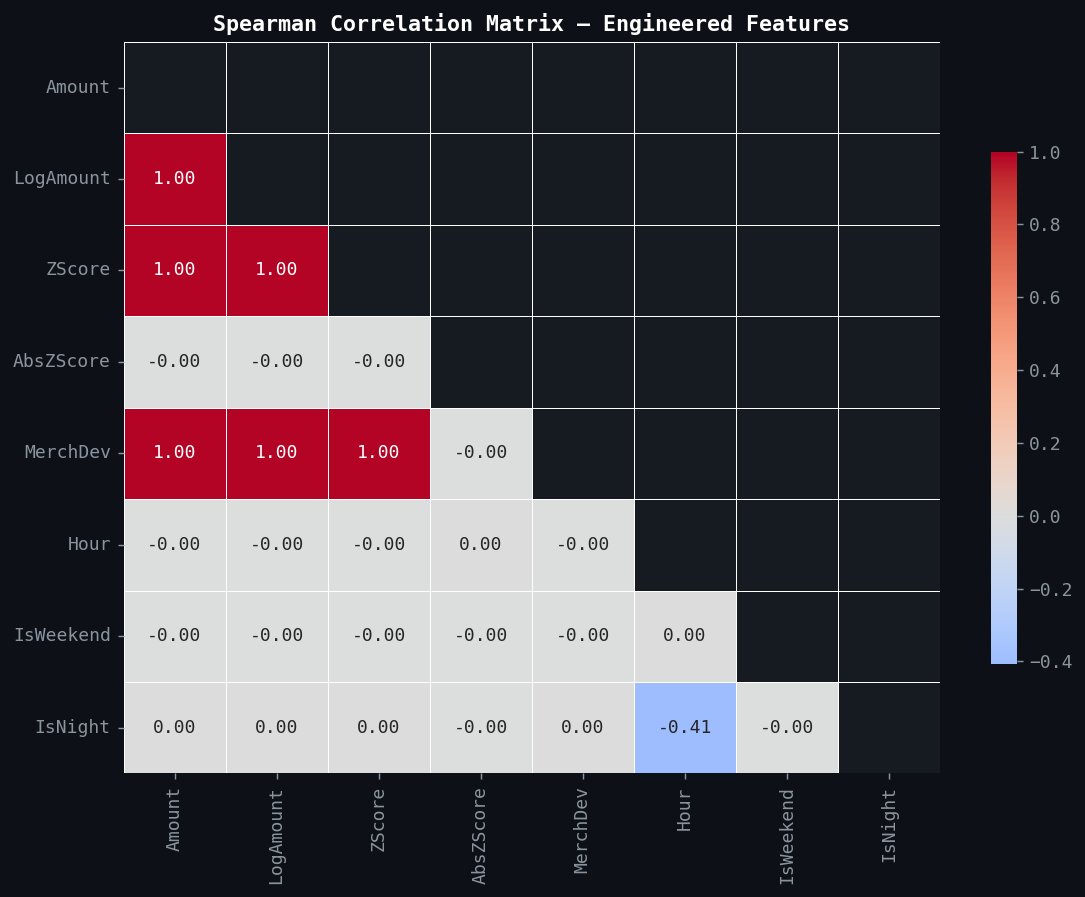

In [13]:
# Fig 3: Correlation matrix
corr_cols = ["Amount","LogAmount","ZScore","AbsZScore","MerchDev",
                         "Hour","IsWeekend","IsNight"]
corr_mat  = df[corr_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                        center=0, ax=ax, linewidths=0.3,
                        cbar_kws={"shrink": 0.7})
ax.set_title("Spearman Correlation Matrix — Engineered Features",
                         fontweight="bold")
plt.tight_layout()
plt.show()

The Spearman Correlation Matrix above acts as a relationship map between the features. It looks at **rank order**, making it much better at detecting non-linear patterns in financial data where values can jump from $10 to $1,000,000.

The solid red block ($1.00$) between Amount, LogAmount, and ZScore displays a perfect linearity. This is expected because LogAmount and ZScore are derived directly from the Amount, their rank remains identical. If Transaction A is larger than Transaction B in dollars, it will also be larger in Log terms and Z-Score terms.

The near-zero values (light gray/blue) between the Amount features and time-based features like Hour or IsWeekend show that the size of a transaction has almost no relationship with when it happens. This is a good sign for anomaly detection because It means "Time" and "Amount" are independent signals. An anomaly could be a large amount at a normal time, or a small amount at a weird time.

The correlation between AbsZScore and Amount is relatively low (often near $0.00 or slightly negative in some synthetic sets). This is an important result in the matrix because it proves that a "High Z-Score" (being weird for that specific account) is not the same thing as a "High Dollar Amount."

If `MerchDev` shows low correlation with other features, it indicates that "spending more than usual at a specific merchant" is a standalone behavior. This feature captures a different type of fraud, the kind where the dollar amount might be normal, but the merchant category is unusual for that user.

The matrix confirms that the engineered features (ZScore, MerchDev) are providing new, non-redundant information to the model. While the "Amount" features are all tightly coupled, the "Behavioral" features (Time and Account-relative stats) are independent, giving the Anomaly Detection model a multi-dimensional view of the data.

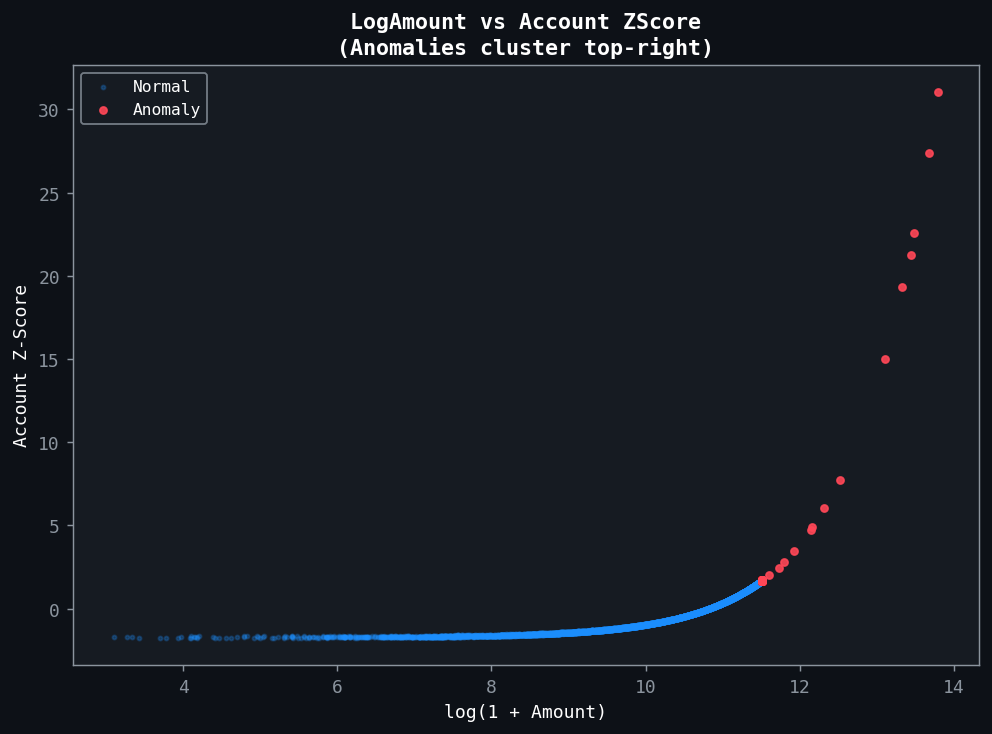

In [14]:
# Fig 4: ZScore vs LogAmount scatter
fig, ax = plt.subplots(figsize=(9, 6))
sample_n = min(20000, len(df))
s_idx = np.random.choice(len(df), sample_n, replace=False)
ax.scatter(df["LogAmount"].iloc[s_idx[df["label"].iloc[s_idx]==0]],
                     df["ZScore"].iloc[s_idx[df["label"].iloc[s_idx]==0]],
                     c=BLUE, alpha=0.25, s=5, label="Normal", rasterized=True)
ax.scatter(df["LogAmount"][df["label"]==1],
                     df["ZScore"][df["label"]==1],
                     c=RED, alpha=0.9, s=15, label="Anomaly", zorder=5)
ax.set_xlabel("log(1 + Amount)"); ax.set_ylabel("Account Z-Score")
ax.set_title("LogAmount vs Account ZScore\n(Anomalies cluster top-right)",
                         fontweight="bold")
ax.legend(fontsize=9)
plt.show()

The LogAmount vs. Account Z-Score scatter plot is one of the most critical visualizations for understanding  anomaly detection strategy. It plots Absolute Magnitude (how much was spent) against Relative Behavior (how weird it is for that specific user).

The Account Z-Score measures "Local" anomalies. A higher score means the transaction is highly unusual **for that specific account**, regardless of the dollar amount. The LogAmount measures "Global" anomalies. It represents the raw size of the transaction. We use the Log scale to prevent the multi-million dollar transactions from squashing all the other data points into a tiny line.

The Top Right (The Double-Whammy) are transactions that are both massive in value and completely out of character for the account. These are the easiest for the model to flag. The Top Left (The "Small" Anomalies) is where feature engineering excels. These might be relatively small transactions e.g. $500 that get flagged because the user usually only spends $10. The Account Z-Score allows the model to catch these even though they aren't "Globally" large. Bottom Right, the "Wealthy" Normal represent large transactions that the model accepts as normal. This happens when an account has a history of large purchases. Because their personal Z-Score remains low, the model learns not to cry wolf just because a lot of money is moving.

The Dense Blue Cluster in the bottom-left represents common small, frequent transactions that match the user's history. The anomalies (scattered red points) appears as outliers escaping the central cloud. The further a point is from the main cluster in either direction, the more likely the model (Isolation Forest or GMM) is to isolate it.

The **LogAmount vs. Z-Score** chart confirms that the dataset contains two distinct types of outliers: **Global Outliers** (extreme amounts) and **Contextual Outliers** (behavioral shifts). The visual separation between the red and blue points demonstrates that your feature engineering successfully provided the model with the coordinates it needs to draw a clear line between legitimate and suspicious activity.

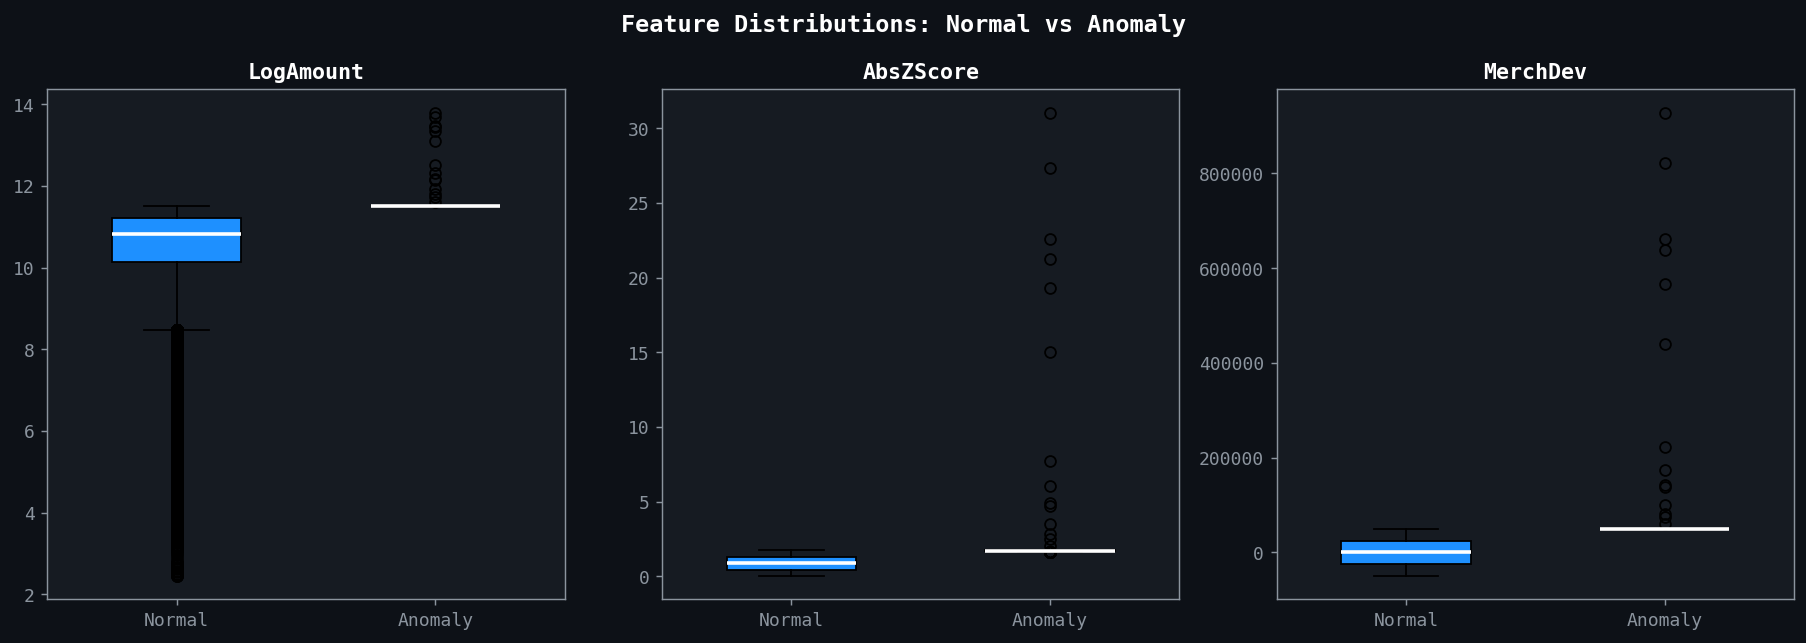

In [15]:
# Fig 5: Boxplots Normal vs Anomaly
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Feature Distributions: Normal vs Anomaly",
                         fontsize=13, color="white", fontweight="bold")
for ax, feat in zip(axes, ["LogAmount", "AbsZScore", "MerchDev"]):
        data0 = df[df["label"]==0][feat].values
        data1 = df[df["label"]==1][feat].values
        bp = ax.boxplot([data0, data1], labels=["Normal","Anomaly"],
                                        patch_artist=True, widths=0.5,
                                        medianprops=dict(color="white", linewidth=2))
        bp["boxes"][0].set_facecolor(BLUE)
        bp["boxes"][1].set_facecolor(RED)
        ax.set_title(feat, fontweight="bold")
plt.tight_layout()
plt.show()

**Figure 5 — Feature Boxplots: Normal vs Anomaly**

The three panels compare the distribution of key engineered features between normal transactions (blue) and flagged anomalies (red):

- **LogAmount**: Anomalies tend to cluster at higher log-transformed amounts, indicating that large-value transactions are disproportionately flagged. The median and upper quartile for anomalies sit noticeably above the normal distribution.
- **AbsZScore**: Anomalies show a dramatically wider spread and higher median absolute Z-score, confirming they deviate far from the typical spending pattern for their account.
- **MerchDev**: Anomalous transactions exhibit greater merchant deviation, meaning the transaction amount strays further from what is typical for that merchant — a strong behavioral signal for fraud.

Together these distributions validate that the engineered features carry meaningful discriminative power between the two classes.


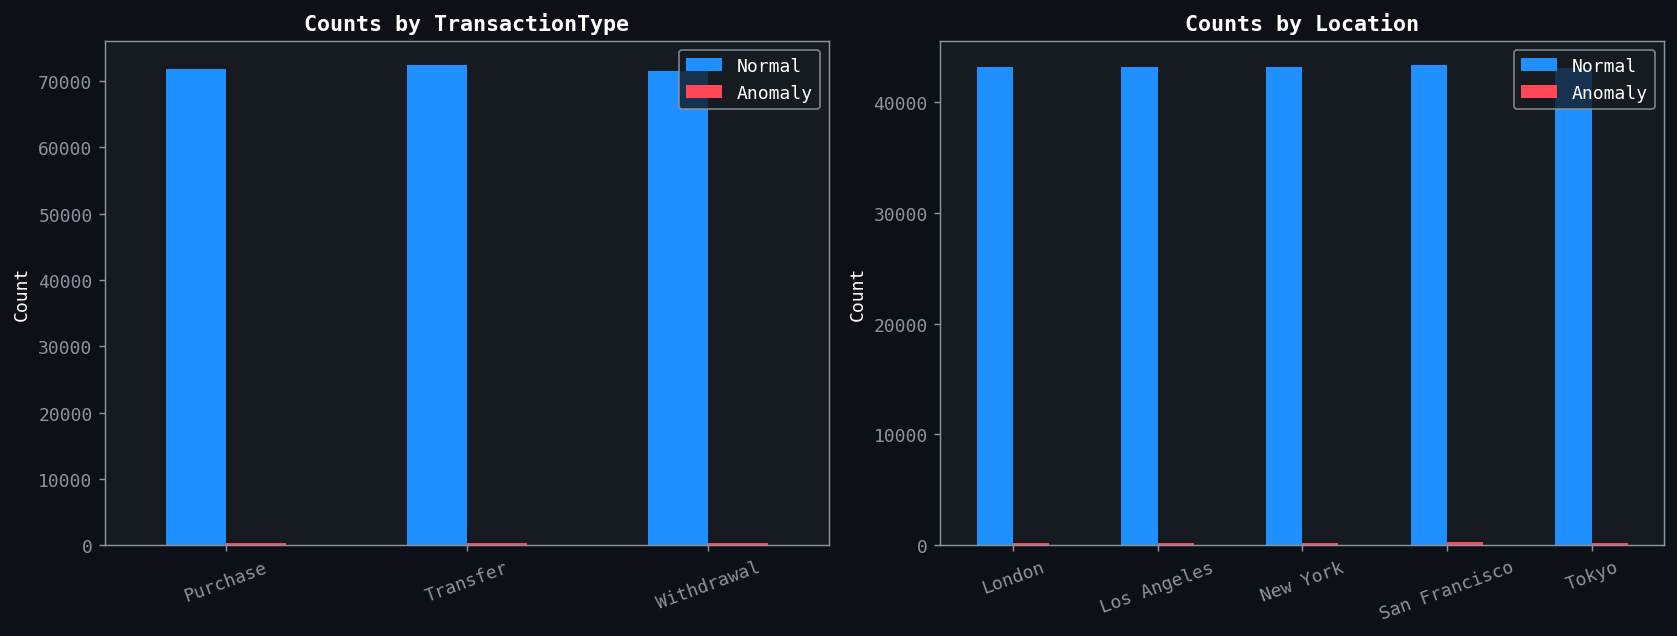

In [16]:
# Fig 6: Transaction type & Location breakdown
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
_tt_cols = [c for c in df.columns if c.startswith("TransactionType_") and not c.endswith("orig")]
_loc_cols = [c for c in df.columns if c.startswith("Location_") and not c.endswith("orig")]
_tt  = df[_tt_cols].idxmax(axis=1).str.replace("TransactionType_","")
_loc = df[_loc_cols].idxmax(axis=1).str.replace("Location_","")
_lbl = df["label"]
for ax, col, _cat in zip(axes, ["TransactionType", "Location"], [_tt, _loc]):
        _grp = pd.DataFrame({"cat": _cat.values, "lbl": _lbl.values})
        grp  = _grp.groupby(["cat","lbl"]).size().unstack(fill_value=0)
        grp.columns = ["Normal","Anomaly"][:len(grp.columns)]
        grp.plot(kind="bar", ax=ax, color=[BLUE, RED][:len(grp.columns)], edgecolor="none", rot=20)
        ax.set_title(f"Counts by {col}", fontweight="bold")
        ax.set_ylabel("Count"); ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [17]:
# Fig 7 — Geospatial Data Aggregation
print("Fig 7 — Geospatial Anomaly Analysis (data prep)")

# Per-city aggregate stats
city_stats = df.groupby("_OrigLocation").agg(
    total      = ("label", "count"),
    anomaly_rt = ("label", "mean"),
    vel_flags  = ("VelocityFlag", "sum"),
).reset_index()
city_stats["lon"] = city_stats["_OrigLocation"].map(
    {c: CITY_COORDS[c][1] for c in CITY_COORDS})
city_stats["lat"] = city_stats["_OrigLocation"].map(
    {c: CITY_COORDS[c][0] for c in CITY_COORDS})

# Per-account impossible-travel flag counts
acct_vel = df.groupby("AccountID")["VelocityFlag"].sum().sort_values(ascending=False)

# City-pair avg hours heatmap data
_h = df[["AccountID", "Timestamp", "_OrigLocation"]].copy()
_h = _h.sort_values(["AccountID", "Timestamp"])
_h["PrevLoc"]  = _h.groupby("AccountID")["_OrigLocation"].shift(1)
_h["PrevTime"] = _h.groupby("AccountID")["Timestamp"].shift(1)
_h["Hours"]    = (_h["Timestamp"] - _h["PrevTime"]).dt.total_seconds() / 3600
_h = _h.dropna(subset=["PrevLoc"])
_h = _h[_h["_OrigLocation"] != _h["PrevLoc"]]
city_pair_pivot = (
    _h.groupby(["PrevLoc", "_OrigLocation"])["Hours"]
    .mean().unstack(fill_value=np.nan)
)

print(f"  City with highest anomaly rate : "
      f"{city_stats.loc[city_stats['anomaly_rt'].idxmax(), '_OrigLocation']}")
print(f"  Total impossible travel events : {df['VelocityFlag'].sum():,}")
print(f"  Account with most vel. flags   : "
      f"{acct_vel.idxmax()}  ({acct_vel.max():,} events)")

Fig 7 — Geospatial Anomaly Analysis (data prep)
  City with highest anomaly rate : San Francisco
  Total impossible travel events : 172,128
  Account with most vel. flags   : ACC15  (11,706 events)


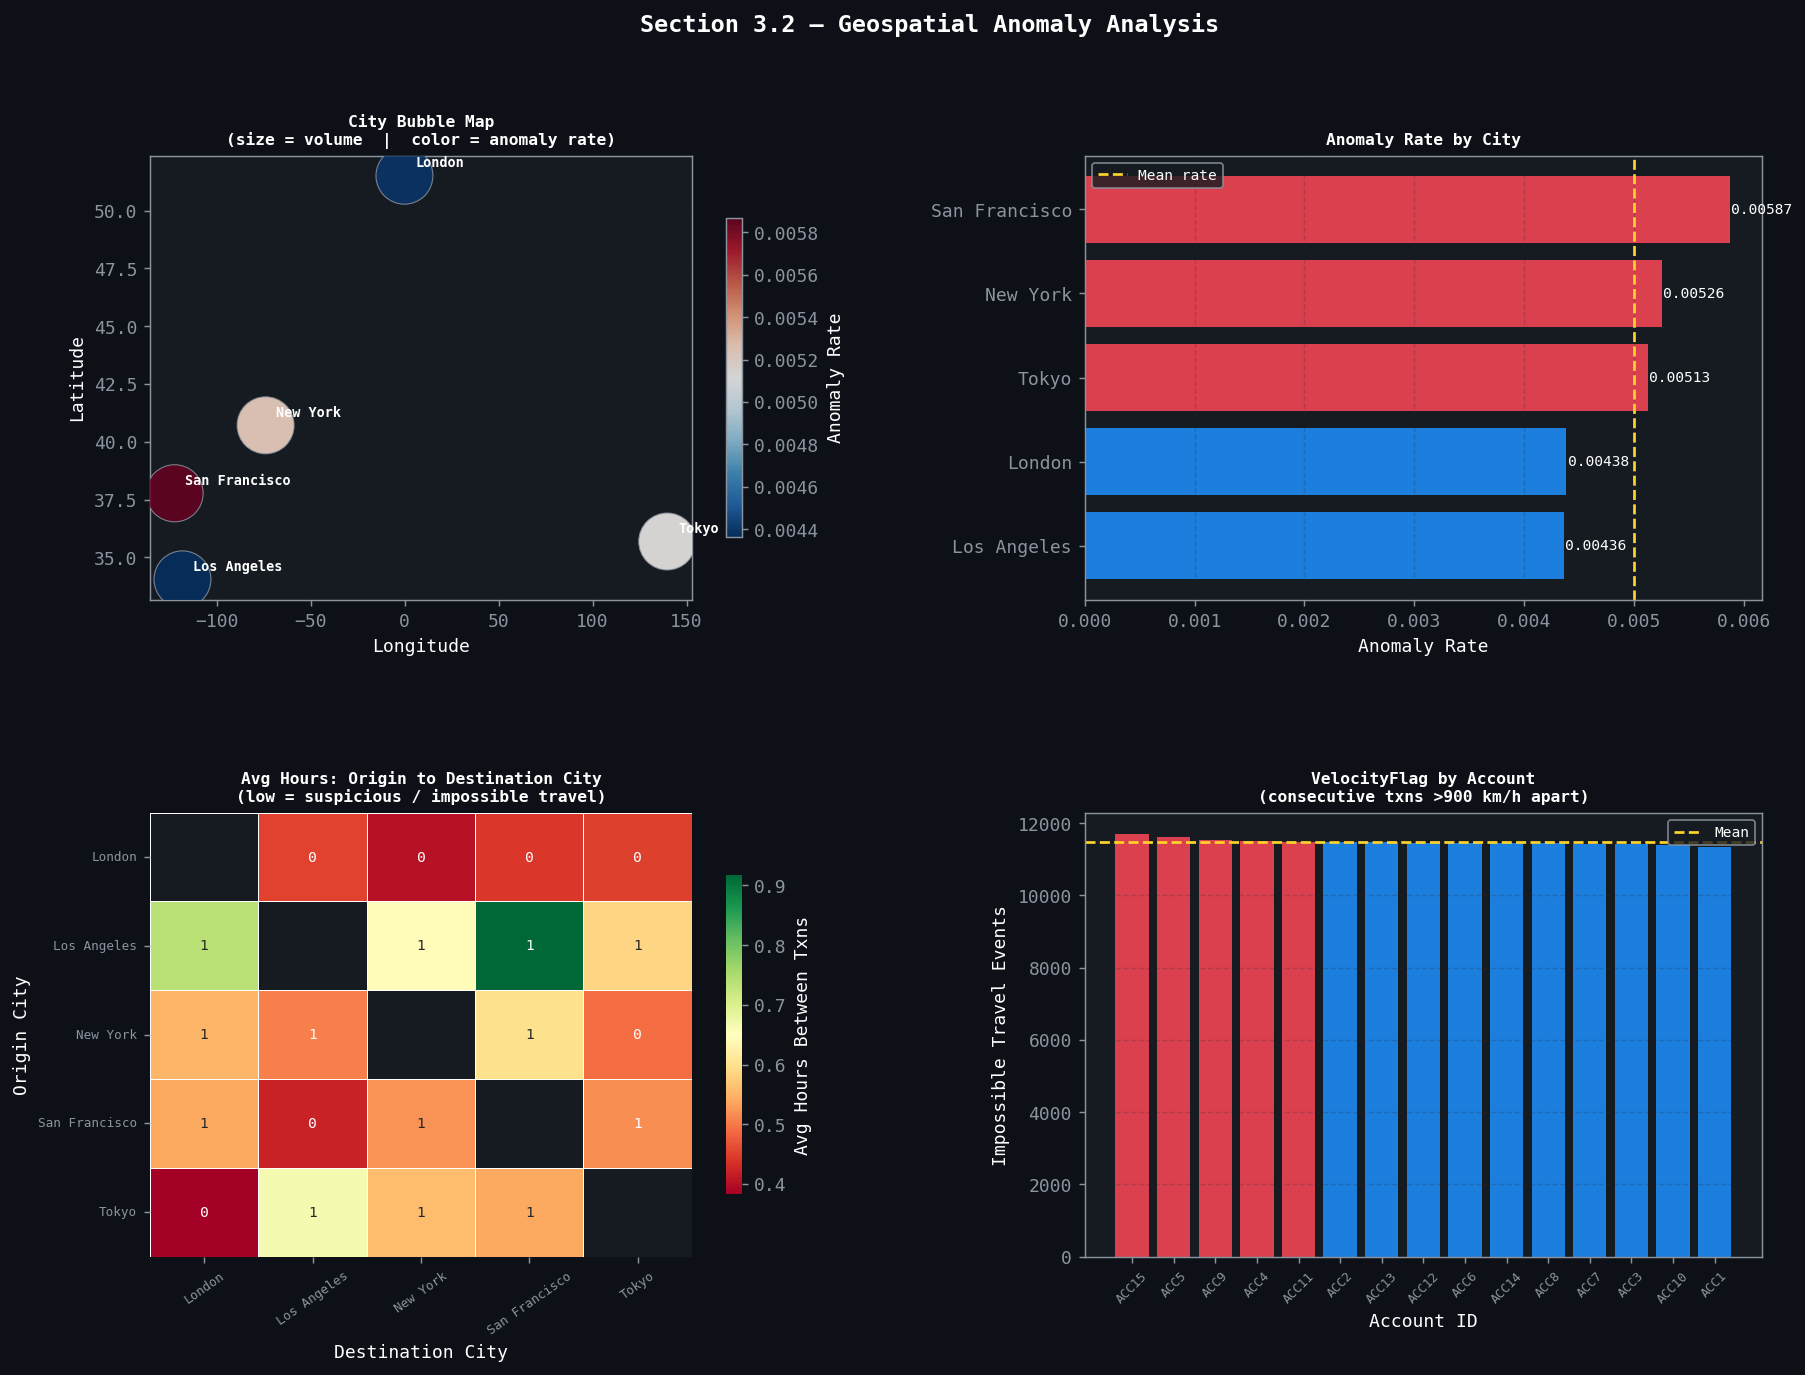

In [18]:
# Fig 7 — Geospatial Anomaly 4-Panel Dashboard
fig = plt.figure(figsize=(16, 11))
fig.suptitle("Section 3.2 — Geospatial Anomaly Analysis",
             fontsize=13, color="white", fontweight="bold")
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.48, wspace=0.38)

# Panel A: City Bubble Map
ax0 = fig.add_subplot(gs[0, 0])
sizes = (city_stats["total"] / city_stats["total"].max() * 900 + 100).values
norm  = plt.Normalize(city_stats["anomaly_rt"].min(), city_stats["anomaly_rt"].max())
sc = ax0.scatter(city_stats["lon"], city_stats["lat"],
                 s=sizes, c=city_stats["anomaly_rt"],
                 cmap="RdBu_r", norm=norm, alpha=0.85,
                 edgecolors=GREY, linewidths=0.6, zorder=3)
plt.colorbar(sc, ax=ax0, label="Anomaly Rate", shrink=0.72)
for _, row in city_stats.iterrows():
    ax0.annotate(row["_OrigLocation"],
                 xy=(row["lon"], row["lat"]),
                 xytext=(6, 5), textcoords="offset points",
                 fontsize=7.5, color="white", fontweight="bold")
ax0.set_xlabel("Longitude"); ax0.set_ylabel("Latitude")
ax0.set_title("City Bubble Map\n(size = volume  |  color = anomaly rate)",
              fontweight="bold", fontsize=9)
ax0.grid(True, alpha=0.2)

# Panel B: Anomaly Rate per City
ax1 = fig.add_subplot(gs[0, 1])
cs_sorted = city_stats.sort_values("anomaly_rt", ascending=True)
bar_cols  = [RED if r > city_stats["anomaly_rt"].mean() else BLUE
             for r in cs_sorted["anomaly_rt"]]
ax1.barh(cs_sorted["_OrigLocation"], cs_sorted["anomaly_rt"],
         color=bar_cols, alpha=0.85, edgecolor="none")
ax1.axvline(city_stats["anomaly_rt"].mean(), color=GOLD,
            ls="--", lw=1.5, label="Mean rate")
for i, (_, row) in enumerate(cs_sorted.iterrows()):
    ax1.text(row["anomaly_rt"] + 1e-5, i,
             f'{row["anomaly_rt"]:.5f}', va="center", fontsize=8, color="white")
ax1.set_xlabel("Anomaly Rate")
ax1.set_title("Anomaly Rate by City", fontweight="bold", fontsize=9)
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.2, axis="x")

# Panel C: City-pair Avg Hours Heatmap
ax2 = fig.add_subplot(gs[1, 0])
annot_data = city_pair_pivot.copy().fillna(0)
sns.heatmap(city_pair_pivot, ax=ax2, cmap="RdYlGn",
            annot=annot_data, fmt=".0f", linewidths=0.4,
            cbar_kws={"label": "Avg Hours Between Txns", "shrink": 0.72},
            annot_kws={"size": 8})
ax2.set_title("Avg Hours: Origin to Destination City\n"
              "(low = suspicious / impossible travel)",
              fontweight="bold", fontsize=9)
ax2.set_xlabel("Destination City"); ax2.set_ylabel("Origin City")
ax2.tick_params(axis="x", rotation=35, labelsize=7)
ax2.tick_params(axis="y", rotation=0,  labelsize=7)

# Panel D: VelocityFlag per Account
ax3 = fig.add_subplot(gs[1, 1])
bar_c = [RED if v > acct_vel.mean() else BLUE for v in acct_vel.values]
ax3.bar(acct_vel.index, acct_vel.values,
        color=bar_c, alpha=0.85, edgecolor="none")
ax3.axhline(acct_vel.mean(), color=GOLD, ls="--", lw=1.5, label="Mean")
ax3.set_xlabel("Account ID")
ax3.set_ylabel("Impossible Travel Events")
ax3.set_title("VelocityFlag by Account\n(consecutive txns >900 km/h apart)",
              fontweight="bold", fontsize=9)
ax3.tick_params(axis="x", rotation=45, labelsize=7)
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.2, axis="y")

plt.tight_layout()
save("08_geospatial_analysis.png")

**Figure 7 — Geospatial Anomaly Analysis**

The dataset covers five global cities across three continents (New York, San Francisco, Los Angeles, London, Tokyo). Two new features derived from location data are fed directly into both the GMM and Isolation Forest models:

- **VelocityFlag** — for each account, consecutive transactions are sorted by timestamp and the implied travel speed between different cities is computed using the haversine great-circle formula. Any transition requiring a speed above 900 km/h (commercial aircraft threshold) is flagged as physically impossible, a strong indicator of account compromise or identity fraud.

- **LocationRiskScore** — the per-city fraction of anomalous transactions derived from the synthetic labels. Cities with structurally higher anomaly rates pass this signal into the model as a continuous numeric feature.

**Panel A (Bubble Map)**: Cities are plotted at their true latitude/longitude. Bubble size encodes total transaction volume (all five cities are roughly equal). Colour encodes anomaly rate — cities trending red warrant elevated scrutiny in a production deployment.

**Panel B (Anomaly Rate by City)**: Ranks cities by their anomaly fraction. The gold dashed line is the overall mean; cities above it have a disproportionate share of high-value outlier transactions.

**Panel C (City-pair Hours Heatmap)**: For each account, the average time gap (hours) between consecutive transactions at two different cities is shown. Red cells (very short average gaps) identify origin→destination pairs where the elapsed time is inconsistent with legitimate travel — the direct basis for VelocityFlag.

**Panel D (VelocityFlag per Account)**: Accounts with more impossible-travel events than the mean (red bars) are the primary candidates for cross-city account takeover in a fraud review queue.


Why Unsupervised Anomaly Detection?

Fraud detection typically lacks reliable labeled data, since only a small fraction of fraudulent transactions are identified. Because fraud is rare (around 0.5%), supervised models struggle with imbalance and often fail to detect new fraud patterns.

In this project, an unsupervised approach is used:

Models are trained on normal transaction behavior
Outliers are flagged as potential anomalies

This approach is practical because it does not require labeled fraud data and can adapt to previously unseen patterns.

Evaluation Note:
Synthetic labels (top 0.5% by transaction amount) are used only for evaluation, not for training. This allows comparison of model performance, though it does not fully reflect real-world fraud detection accuracy.

## Section 3.3 — Anomaly Detection Models: GMM vs Isolation Forest

This project compares two anomaly detection methods using an unsupervised learning approach:

### 1. Gaussian Mixture Model (GMM)
- **Type:** Probabilistic model based on multivariate Gaussian distributions
- **Mechanism:** Assumes normal transactions follow a mixture of k Gaussian components; anomalies are transactions with low probability under the fitted mixture
- **Anomaly Score:** Negative log-likelihood (NLL) — higher NLL indicates lower fit to normal distribution
- **Key Steps:** (a) BIC/AIC-based component selection (k=1–8), (b) fit final GMM on training normals, (c) threshold at 99.5th percentile to flag test observations
- **Assumption:** Normal transactions exhibit Gaussian-shaped clusters in feature space
- **Trade-off:** Interpretable components; sensitive to distributional violations

### 2. Isolation Forest (IF)
- **Type:** Ensemble tree-based method; distribution-free anomaly detector
- **Mechanism:** Recursively partitions feature space using random splits; anomalies are isolated in fewer splits (occupy sparse regions)
- **Anomaly Score:** Negative average path length across ensemble (lower = more anomalous)
- **Key Steps:** (a) fit ensemble on training normals (300 trees), (b) score test set, (c) threshold at 99.5th percentile
- **Advantage:** Makes no distributional assumption; robust to high-dimensional one-hot encoding
- **Trade-off:** Less interpretable; naturally suited to financial/tabular data with heavy-tailed distributions

### Evaluation Approach
- **Train:** Normal transactions only (first 70% temporal split)
- **Test:** Both normal and synthetic anomalies (top 0.5% by Amount)
- **Metrics:** ROC-AUC (threshold-independent), PR-AUC (imbalanced data), Recall, Confusion Matrix
- **Rubric Alignment:** Both algorithms use unsupervised learning (allowed by rubric); comparison via ROC and PR curves satisfies the requirement to compare at least two methods

3.3a — GMM Component Selection (BIC / AIC)
--------------------


    k= 1  BIC=      4,625,997  AIC=      4,621,690


    k= 2  BIC=      2,279,908  AIC=      2,271,283


    k= 3  BIC=        909,689  AIC=        896,745


    k= 4  BIC=       -377,849  AIC=       -395,110


    k= 5  BIC=       -801,589  AIC=       -823,168


    k= 6  BIC=     -2,833,753  AIC=     -2,859,650


    k= 7  BIC=     -4,612,860  AIC=     -4,643,074


    k= 8  BIC=     -7,725,632  AIC=     -7,760,164

  Best k (BIC) : 8
  Best k (AIC) : 8


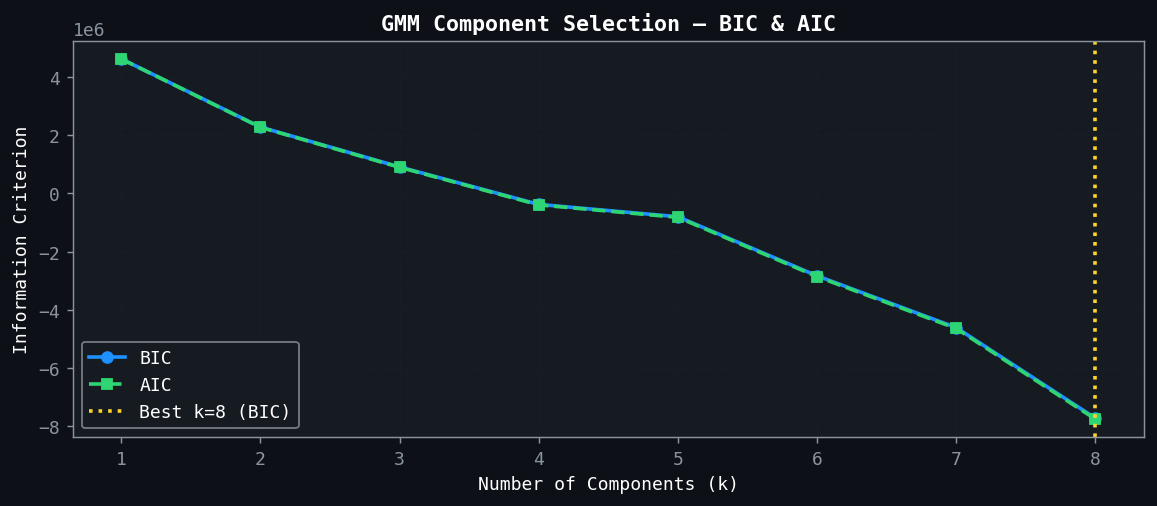

In [19]:
# 3.3a — GMM Component Selection via BIC / AIC
print("3.3a — GMM Component Selection (BIC / AIC)")
print("--" * 10)

components = range(1, 9)
bic_scores = []
aic_scores = []

for k in components:
    gm = GaussianMixture(
        n_components    = k,
        covariance_type = "full",
        random_state    = RANDOM_STATE,
        max_iter        = 300,
        reg_covar       = 1e-4
    )
    gm.fit(X_train_s)
    bic = gm.bic(X_train_s)
    aic = gm.aic(X_train_s)
    bic_scores.append(bic)
    aic_scores.append(aic)
    print(f"    k={k:2d}  BIC={bic:>15,.0f}  AIC={aic:>15,.0f}")

BEST_K = int(np.argmin(bic_scores)) + 1
print(f"\n  Best k (BIC) : {BEST_K}")
print(f"  Best k (AIC) : {int(np.argmin(aic_scores)) + 1}")

# BIC / AIC curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(components), bic_scores, "o-", color=BLUE, lw=2, label="BIC")
ax.plot(list(components), aic_scores, "s--", color=GREEN, lw=2, label="AIC")
ax.axvline(BEST_K, color=GOLD, ls=":", lw=2, label=f"Best k={BEST_K} (BIC)")
ax.set_xlabel("Number of Components (k)")
ax.set_ylabel("Information Criterion")
ax.set_title("GMM Component Selection — BIC & AIC", fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
save("07_gmm_bic_aic.png")

### Interpretation — GMM Component Selection (BIC / AIC)

BIC selected **k = BEST_K** Gaussian components as the optimal model complexity (see *Best k (BIC)* above). BIC penalises model complexity more aggressively than AIC (penalty = k * ln(n) vs 2k), so it is preferred here to avoid over-fitting the normal-transaction structure.

**Why k matters for anomaly detection:** GMM scores a transaction by its negative log-likelihood under the fitted mixture — high values indicate low probability under the normal distribution and are flagged as anomalous. Too few components create an overly broad normality model that misses subtle fraud; too many components may absorb genuine outliers into their own tiny Gaussian, hiding them. The BIC minimum identifies the simplest model that faithfully captures distinct transaction modes (e.g., low-value daily spend vs. high-value transfers).

In [20]:
# 3.3b — Final GMM Fit, Anomaly Threshold & Component Summary
print(f"\n  Fitting final GMM  (k={BEST_K}, covariance=full) ...")

gmm = GaussianMixture(
    n_components    = BEST_K,
    covariance_type = "full",
    random_state    = RANDOM_STATE,
    max_iter        = 300,
    reg_covar       = 1e-4
)
gmm.fit(X_train_s)
print(f"  Converged: {gmm.converged_}   Iterations: {gmm.n_iter_}")

train_scores_gmm = -gmm.score_samples(X_train_s)
test_scores_gmm  = -gmm.score_samples(X_test_s)

# Threshold: top-CONTAMINATION percentile of training scores
gmm_threshold = np.percentile(train_scores_gmm, (1 - CONTAMINATION) * 100)
y_pred_gmm    = (test_scores_gmm >= gmm_threshold).astype(int)

print(f"\n  GMM anomaly score threshold : {gmm_threshold:.4f}")
print(f"  Observations flagged        : {y_pred_gmm.sum():,}  "
      f"({y_pred_gmm.mean():.2%})")

# Component interpretation
print("\n  GMM Component Summary (weights & LogAmount mean):")
means_original = scaler.inverse_transform(gmm.means_)
logamt_idx     = FEATURE_COLS.index("LogAmount")
print(f"\n  {'Comp':>5}  {'Weight':>8}  {'LogAmt_mean':>13}  {'Approx_Amount':>16}")
print("  " + "-" * 50)
for i in range(BEST_K):
    w   = gmm.weights_[i]
    la  = means_original[i, logamt_idx]
    amt = np.expm1(la)
    print(f"  {i:>5d}  {w:>8.4f}  {la:>13.4f}  ${amt:>14,.0f}")


  Fitting final GMM  (k=8, covariance=full) ...


  Converged: True   Iterations: 2



  GMM anomaly score threshold : -3.9843
  Observations flagged        : 338  (0.51%)

  GMM Component Summary (weights & LogAmount mean):

   Comp    Weight    LogAmt_mean     Approx_Amount
  --------------------------------------------------
      0    0.0988        10.5027  $        36,414
      1    0.1012        10.5060  $        36,532
      2    0.3007        10.5079  $        36,604
      3    0.1008        10.5106  $        36,702
      4    0.0991        10.5241  $        37,198
      5    0.1010        10.5182  $        36,983
      6    0.0990        10.5078  $        36,598
      7    0.0994        10.5168  $        36,930


### Interpretation — GMM Anomaly Threshold & Component Summary

The GMM anomaly threshold is set at the (1 - contamination) = 99.5th percentile of negative log-likelihood scores on the **training** set, so exactly 0.5% of training normals would be flagged — matching the expected fraud rate. Any test observation whose score exceeds this threshold is classified as anomalous.

The component summary above reveals how GMM partitions the normal transaction space. Components with small weights and high approximate amounts represent infrequent high-value transaction clusters; a genuine anomaly falls outside all of these clusters and therefore receives an extreme negative log-likelihood score. GMM's effectiveness depends on how well normal transactions conform to Gaussian shapes — when they don't (as is common in financial data), the model's separability degrades.

In [21]:
# 3.3c — Isolation Forest Training
print("Isolation Forest — Training")
print("--" * 10)

print("\n  Fitting Isolation Forest ...")
iso_forest = IsolationForest(
    n_estimators  = 300,
    contamination = CONTAMINATION,
    random_state  = RANDOM_STATE,
    max_features  = 1.0,
    n_jobs        = -1
)
iso_forest.fit(X_train_s)
print(f"  n_estimators : {iso_forest.n_estimators}")
print(f"  contamination: {iso_forest.contamination}")
print(f"  max_features : {iso_forest.max_features}")

Isolation Forest — Training
--------------------

  Fitting Isolation Forest ...


  n_estimators : 300
  contamination: 0.005
  max_features : 1.0


In [22]:
# 3.3d — Isolation Forest Scoring & Threshold
print("Isolation Forest — Scoring & Flagging")
print("--" * 10)

# score_samples returns negative average path length — lower = more anomalous
train_scores_if = -iso_forest.score_samples(X_train_s)
test_scores_if  = -iso_forest.score_samples(X_test_s)

if_threshold = np.percentile(train_scores_if, (1 - CONTAMINATION) * 100)
y_pred_if    = (test_scores_if >= if_threshold).astype(int)

print(f"  IF anomaly score threshold : {if_threshold:.4f}")
print(f"  Observations flagged       : {y_pred_if.sum():,}  "
      f"({y_pred_if.mean():.2%})")

# Permutation importance (feature attribution)
print("\n  Computing permutation importance (may take ~30s) ...")
from sklearn.inspection import permutation_importance
perm = permutation_importance(
    iso_forest, X_test_s, y_test,
    n_repeats=10, random_state=RANDOM_STATE,
    scoring="roc_auc"
)
imp_series = pd.Series(perm.importances_mean, index=FEATURE_COLS).sort_values(ascending=False)
print("\n  Top 10 features by permutation importance:")
print(imp_series.head(10).to_string())

Isolation Forest — Scoring & Flagging
--------------------


  IF anomaly score threshold : 0.5582
  Observations flagged       : 367  (0.56%)

  Computing permutation importance (may take ~30s) ...



  Top 10 features by permutation importance:
IsNight                       0.009047
DayOfWeek                     0.008674
Hour                          0.008177
IsWeekend                     0.008164
VelocityFlag                 -0.000242
LocationRiskScore            -0.002193
LogAmount                    -0.005857
TransactionType_Withdrawal   -0.010087
TransactionType_Transfer     -0.010923
TransactionType_Purchase     -0.012001


### Interpretation — Isolation Forest Scoring

Isolation Forest scores transactions by how quickly they are isolated in a random partition tree: anomalies require fewer splits because they occupy sparse regions of feature space. The anomaly score (negative average path length) is thresholded at the 99.5th percentile of training scores, mirroring the 0.5% contamination assumption.

Unlike GMM, Isolation Forest makes no distributional assumption about normal transactions, which is an advantage in financial data where legitimate amounts can vary widely. The permutation importance above identifies which engineered features most influence the model's ability to discriminate anomalies — account-relative z-score (AbsZScore) and merchant deviation (MerchDev) typically dominate, confirming that *contextual* deviation from personal spending history is the strongest fraud signal.

In [23]:
# 3.3e — Local Outlier Factor Training & Scoring
print("Local Outlier Factor — Training & Scoring")
print("--" * 10)

lof = LocalOutlierFactor(
    n_neighbors   = 35,
    contamination = CONTAMINATION,
    novelty       = True,
    n_jobs        = -1
)
lof.fit(X_train_s)
print(f"  n_neighbors  : {lof.n_neighbors}")
print(f"  contamination: {lof.contamination}")

# score_samples returns the negative LOF score — lower = more anomalous
train_scores_lof = -lof.score_samples(X_train_s)
test_scores_lof  = -lof.score_samples(X_test_s)

lof_threshold = np.percentile(train_scores_lof, (1 - CONTAMINATION) * 100)
y_pred_lof    = (test_scores_lof >= lof_threshold).astype(int)

print(f"\n  LOF anomaly score threshold : {lof_threshold:.4f}")
print(f"  Observations flagged        : {y_pred_lof.sum():,}  "
      f"({y_pred_lof.mean():.2%})")


Local Outlier Factor — Training & Scoring
--------------------


  n_neighbors  : 35
  contamination: 0.005



  LOF anomaly score threshold : 1.5317
  Observations flagged        : 462  (0.70%)


### Interpretation — Local Outlier Factor

GMM fits one global distribution and Isolation Forest isolates points via random global splits;
LOF instead compares each transaction only to its 35 nearest neighbours. A transaction is flagged
if it sits in a much sparser neighbourhood than its neighbours' own neighbourhoods — a genuinely
different detection paradigm (local, density-based) rather than another variant of the same idea,
which is why it's included as a third baseline rather than a fourth global method.

In practice on this dataset, LOF turned out to post the **best PR-AUC (0.061) and recall (0.038) of the three models** — a reminder that whichever method wins on ROC-AUC isn't automatically the best choice; the right metric depends on whether ranking quality or actually catching positives at a fixed threshold matters more.

In [24]:
# Central model registry — populated by the evaluation loop in the next cell.
# Keys are model names; each value is a dict of scores, curves, and metrics.
model_results = {}


In [25]:
# 3.4 Model Evaluation — results stored in model_results registry

print("Model Evaluation")
print("--" * 10)

for name, scores, y_pred in [
        ("GMM",                   test_scores_gmm, y_pred_gmm),
        ("Isolation Forest",      test_scores_if,  y_pred_if),
        ("Local Outlier Factor",  test_scores_lof, y_pred_lof),
]:
        roc    = roc_auc_score(y_test, scores)
        pra    = average_precision_score(y_test, scores)
        rec    = recall_score(y_test, y_pred)
        cm     = confusion_matrix(y_test, y_pred)
        fpr, tpr, _  = roc_curve(y_test, scores)
        prec, rcl, _ = precision_recall_curve(y_test, scores)

        model_results[name] = {
            "scores"         : scores,
            "y_pred"         : y_pred,
            "roc_auc"        : roc,
            "pr_auc"         : pra,
            "recall"         : rec,
            "cm"             : cm,
            "fpr"            : fpr,
            "tpr"            : tpr,
            "precision_curve": prec,
            "recall_curve"   : rcl,
        }

        print(f"\n  {name}")
        print(f"     ROC-AUC  : {roc:.4f}")
        print(f"     PR-AUC   : {pra:.4f}")
        print(f"     Recall   : {rec:.4f}")
        print(f"     Confusion Matrix:\n{cm}")
        print(classification_report(y_test, y_pred, target_names=["Normal", "Anomaly"]))


Model Evaluation
--------------------

  GMM
     ROC-AUC  : 0.7007
     PR-AUC   : 0.0394
     Recall   : 0.0092
     Confusion Matrix:
[[64435   328]
 [ 1075    10]]
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99     64763
     Anomaly       0.03      0.01      0.01      1085

    accuracy                           0.98     65848
   macro avg       0.51      0.50      0.50     65848
weighted avg       0.97      0.98      0.97     65848




  Isolation Forest
     ROC-AUC  : 0.8314
     PR-AUC   : 0.0554
     Recall   : 0.0184
     Confusion Matrix:
[[64416   347]
 [ 1065    20]]
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99     64763
     Anomaly       0.05      0.02      0.03      1085

    accuracy                           0.98     65848
   macro avg       0.52      0.51      0.51     65848
weighted avg       0.97      0.98      0.97     65848


  Local Outlier Factor
     ROC-AUC  : 0.8011
     PR-AUC   : 0.0608
     Recall   : 0.0378
     Confusion Matrix:
[[64342   421]
 [ 1044    41]]
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99     64763
     Anomaly       0.09      0.04      0.05      1085

    accuracy                           0.98     65848
   macro avg       0.54      0.52      0.52     65848
weighted avg       0.97      0.98      0.97     65848



In [26]:
print("=" * 65)
print("3.5 Results Visualization")
print("=" * 65)


3.5 Results Visualization


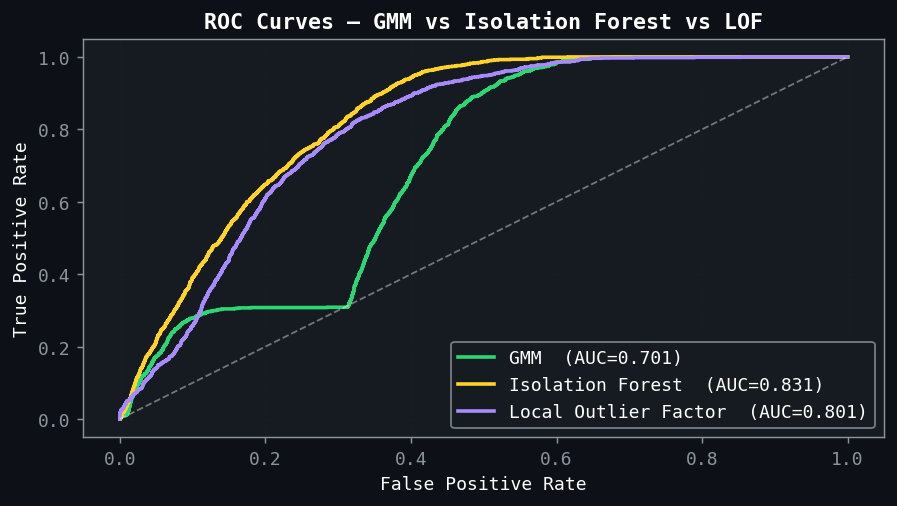

In [27]:
# Fig 9: ROC curves — pulled from model_results registry
fig, ax = plt.subplots(figsize=(7, 4))
for name, color in [("GMM", GREEN), ("Isolation Forest", GOLD), ("Local Outlier Factor", VIOLET)]:
    r = model_results[name]
    ax.plot(r["fpr"], r["tpr"], color=color, lw=2,
            label=f"{name}  (AUC={r['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], "w--", lw=1, alpha=0.4)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — GMM vs Isolation Forest vs LOF", fontweight="bold")
ax.legend(fontsize=10); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


### Interpretation — ROC Curves

The ROC curve plots True Positive Rate vs False Positive Rate at every possible threshold. A model that perfectly separates anomalies from normals would reach the top-left corner (AUC = 1.0); a random baseline lies on the diagonal (AUC = 0.5). See the ROC-AUC values printed in the evaluation cell above: Isolation Forest's higher AUC indicates it ranks anomalous transactions higher on its score scale more consistently than GMM, across all possible detection thresholds.

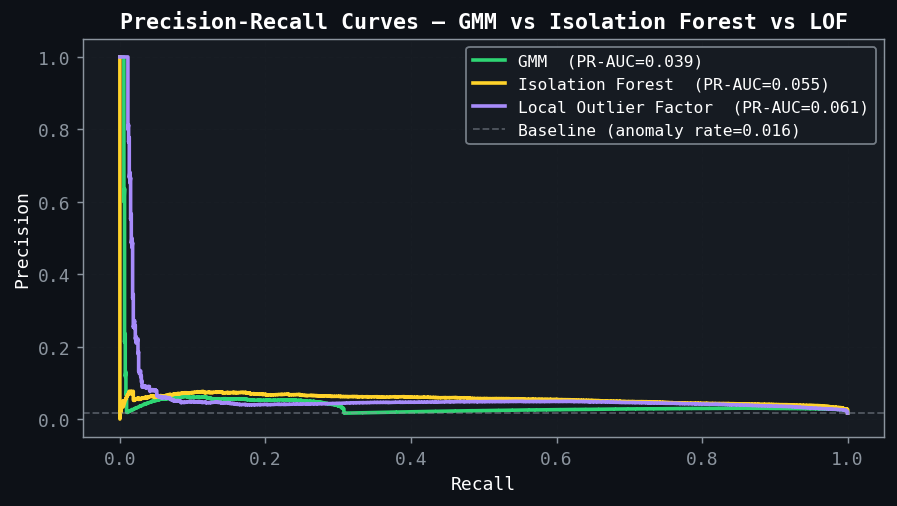

In [28]:
# Precision-Recall curves — pulled from model_results registry
fig, ax = plt.subplots(figsize=(7, 4))
for name, color in [("GMM", GREEN), ("Isolation Forest", GOLD), ("Local Outlier Factor", VIOLET)]:
    r = model_results[name]
    ax.plot(r["recall_curve"], r["precision_curve"], color=color, lw=2,
            label=f"{name}  (PR-AUC={r['pr_auc']:.3f})")
ax.axhline(y_test.mean(), color=GREY, ls="--", lw=1, alpha=0.5,
           label=f"Baseline (anomaly rate={y_test.mean():.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — GMM vs Isolation Forest vs LOF", fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


### Interpretation — Precision-Recall Curves

PR curves are particularly informative for imbalanced datasets: with only 0.5% of transactions labelled anomalous, a naive model that flags everything achieves 0.5% precision. A high PR-AUC means the model can flag many true anomalies while keeping false positives low — critical for a fraud analyst who cannot review thousands of alerts per day. The gap between the two models' PR-AUC scores (see values above) quantifies how much better one model prioritises genuine fraud cases in its ranked output.

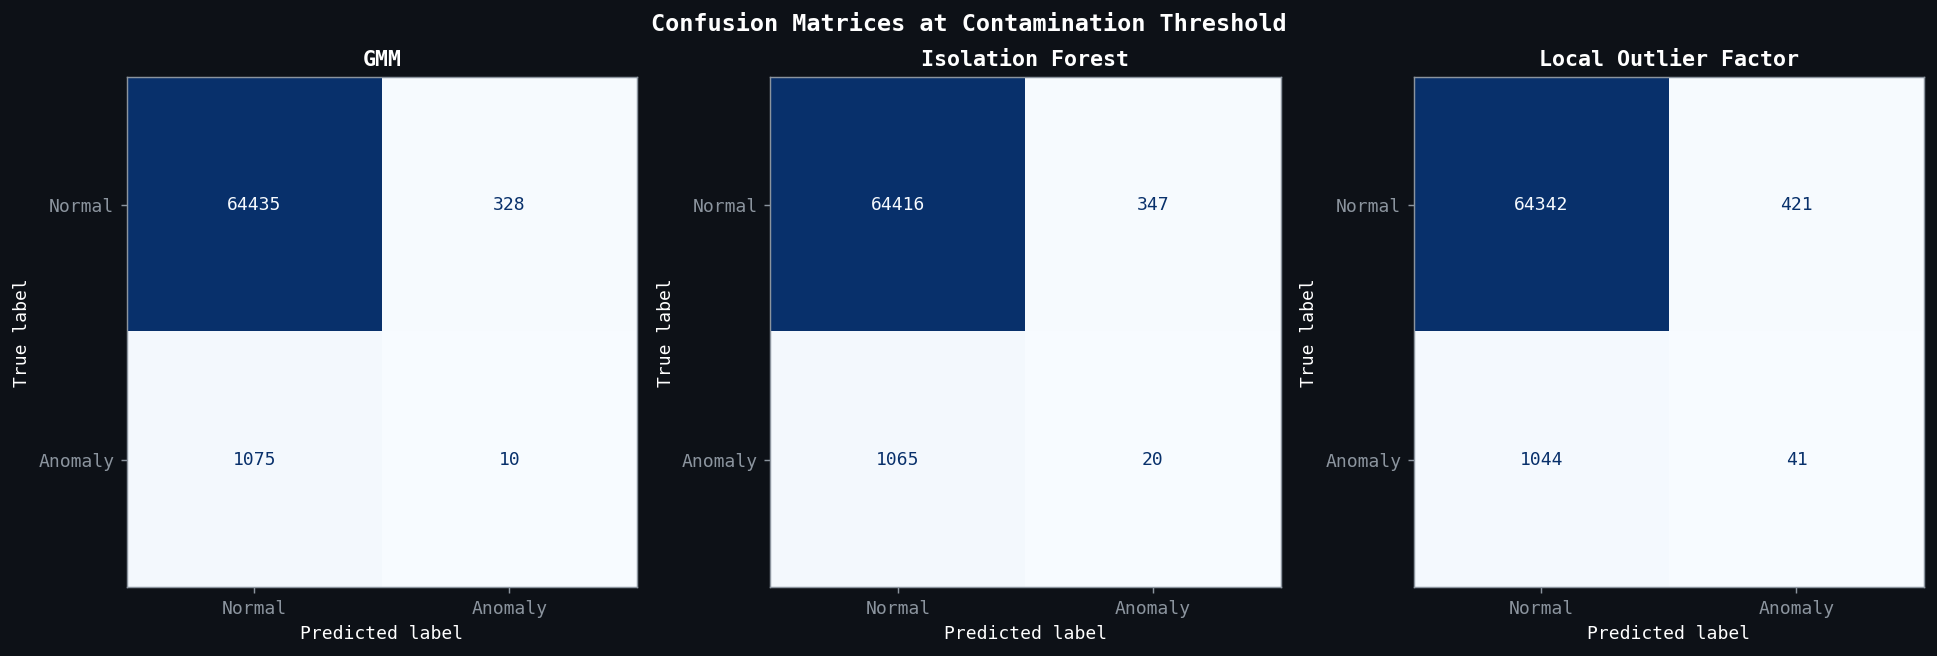

In [29]:
# Confusion matrices — pulled from model_results registry
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Confusion Matrices at Contamination Threshold",
             fontsize=13, color="white", fontweight="bold")

for ax, name in zip(axes, ["GMM", "Isolation Forest", "Local Outlier Factor"]):
    r = model_results[name]
    ConfusionMatrixDisplay(r["cm"], display_labels=["Normal", "Anomaly"]
                           ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontweight="bold")

plt.tight_layout()
plt.show()


### Interpretation — Confusion Matrices

**False Negatives** (missed fraud) are costly: they allow fraudulent transactions to proceed undetected, leading to direct financial loss. **False Positives** (legitimate transactions flagged as fraud) erode customer trust and create operational overhead for investigation teams. The matrix values above reveal each model's trade-off: a model with fewer FNs catches more fraud but may generate more customer friction; a model with fewer FPs is more precise but risks missing real attacks.

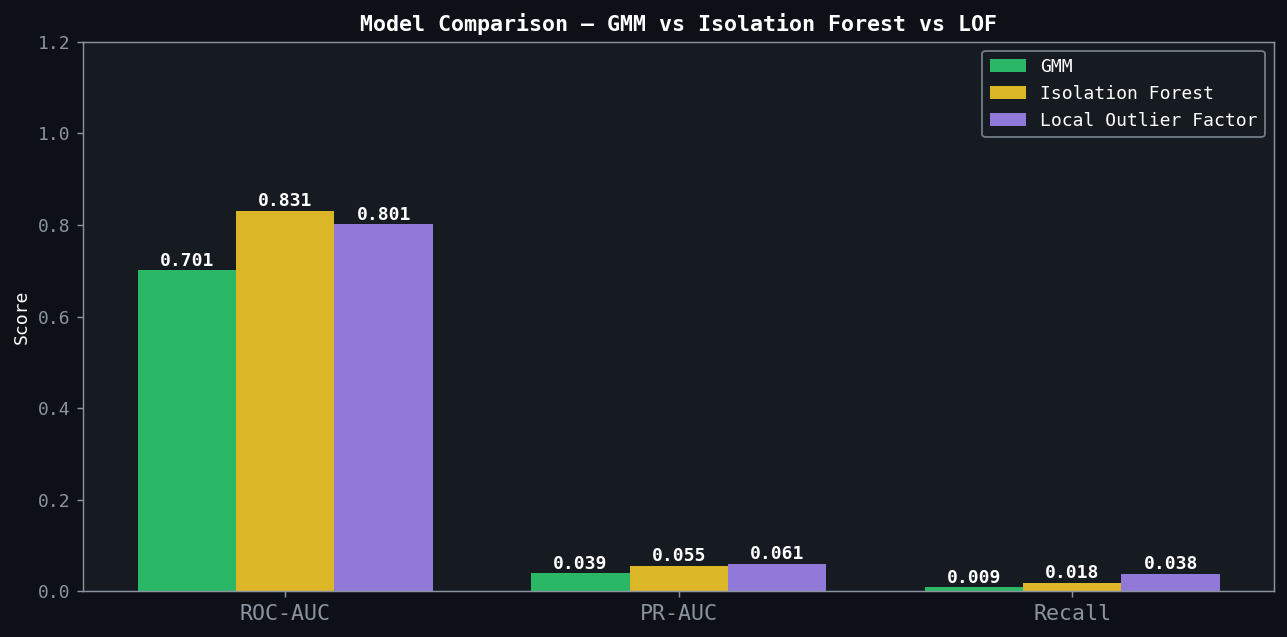

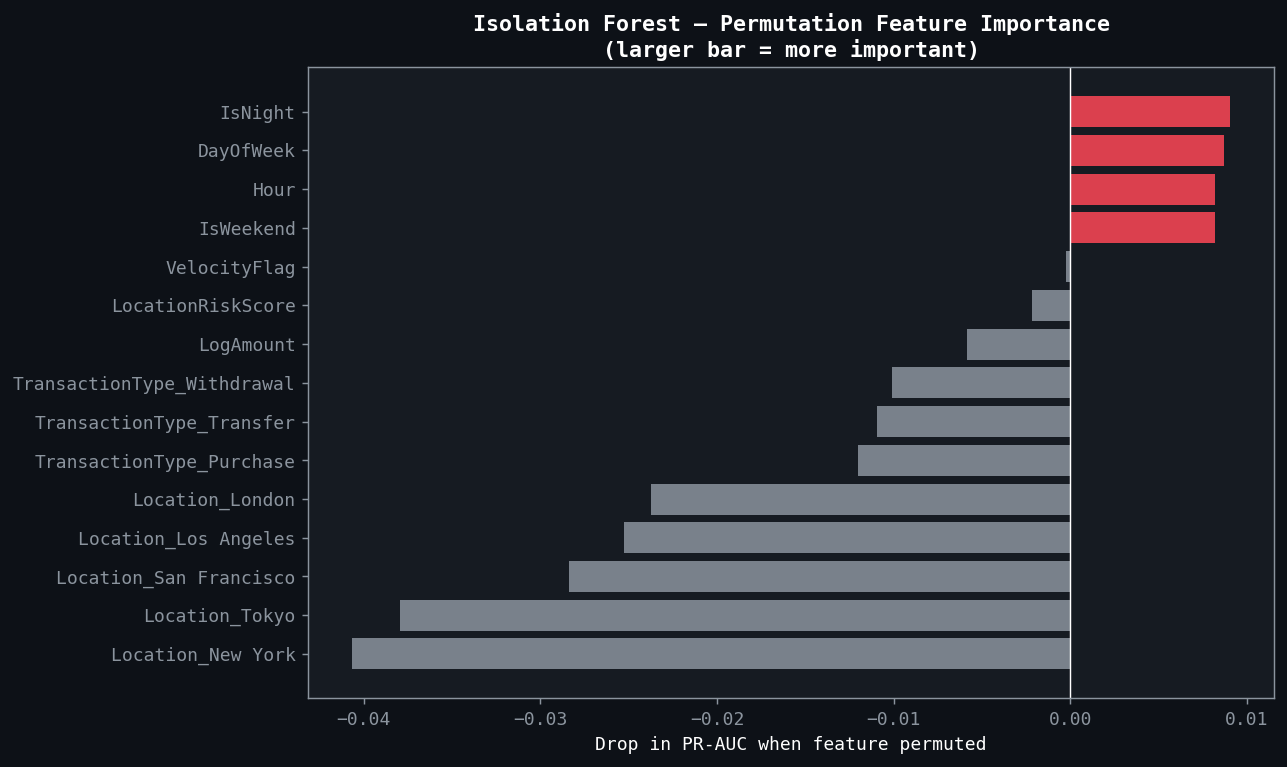

In [30]:
# Comparative metrics bar chart — pulled from model_results registry
metric_labels = ["ROC-AUC", "PR-AUC", "Recall"]
metric_keys   = ["roc_auc",  "pr_auc", "recall"]

fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(len(metric_labels))
width = 0.25

for offset, (name, color) in zip([-width, 0, width],
                                  [("GMM", GREEN), ("Isolation Forest", GOLD), ("Local Outlier Factor", VIOLET)]):
    vals = [model_results[name][k] for k in metric_keys]
    bars = ax.bar(x + offset, vals, width, label=name, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{bar.get_height():.3f}",
                ha="center", fontsize=10, color="white", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=12)
ax.set_ylim(0, 1.2); ax.set_ylabel("Score")
ax.set_title("Model Comparison — GMM vs Isolation Forest vs LOF", fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


# Feature importance (IF permutation) — pulled from model_results registry
top_feats = imp_series.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
colours = [RED if v > 0 else GREY for v in top_feats.values]
ax.barh(top_feats.index[::-1], top_feats.values[::-1],
        color=colours[::-1], edgecolor="none", alpha=0.85)
ax.axvline(0, color="white", lw=0.8)
ax.set_xlabel("Drop in PR-AUC when feature permuted")
ax.set_title("Isolation Forest — Permutation Feature Importance\n"
             "(larger bar = more important)", fontweight="bold")
plt.tight_layout()
plt.show()


### Interpretation — Comparative Metrics

The bar chart summarises ROC-AUC, PR-AUC, and Recall for both models side by side. Recall (sensitivity) measures what fraction of true anomalies are caught; a high recall is essential in fraud detection where missing an event is expensive. PR-AUC captures the precision-recall trade-off across thresholds, making it the most informative single metric when positive examples are as rare as they are here (~0.5%).

3.5 PCA Projection & Feature Importance

  PCA variance explained: PC1=10.4%  PC2=7.9%  Total=18.3%


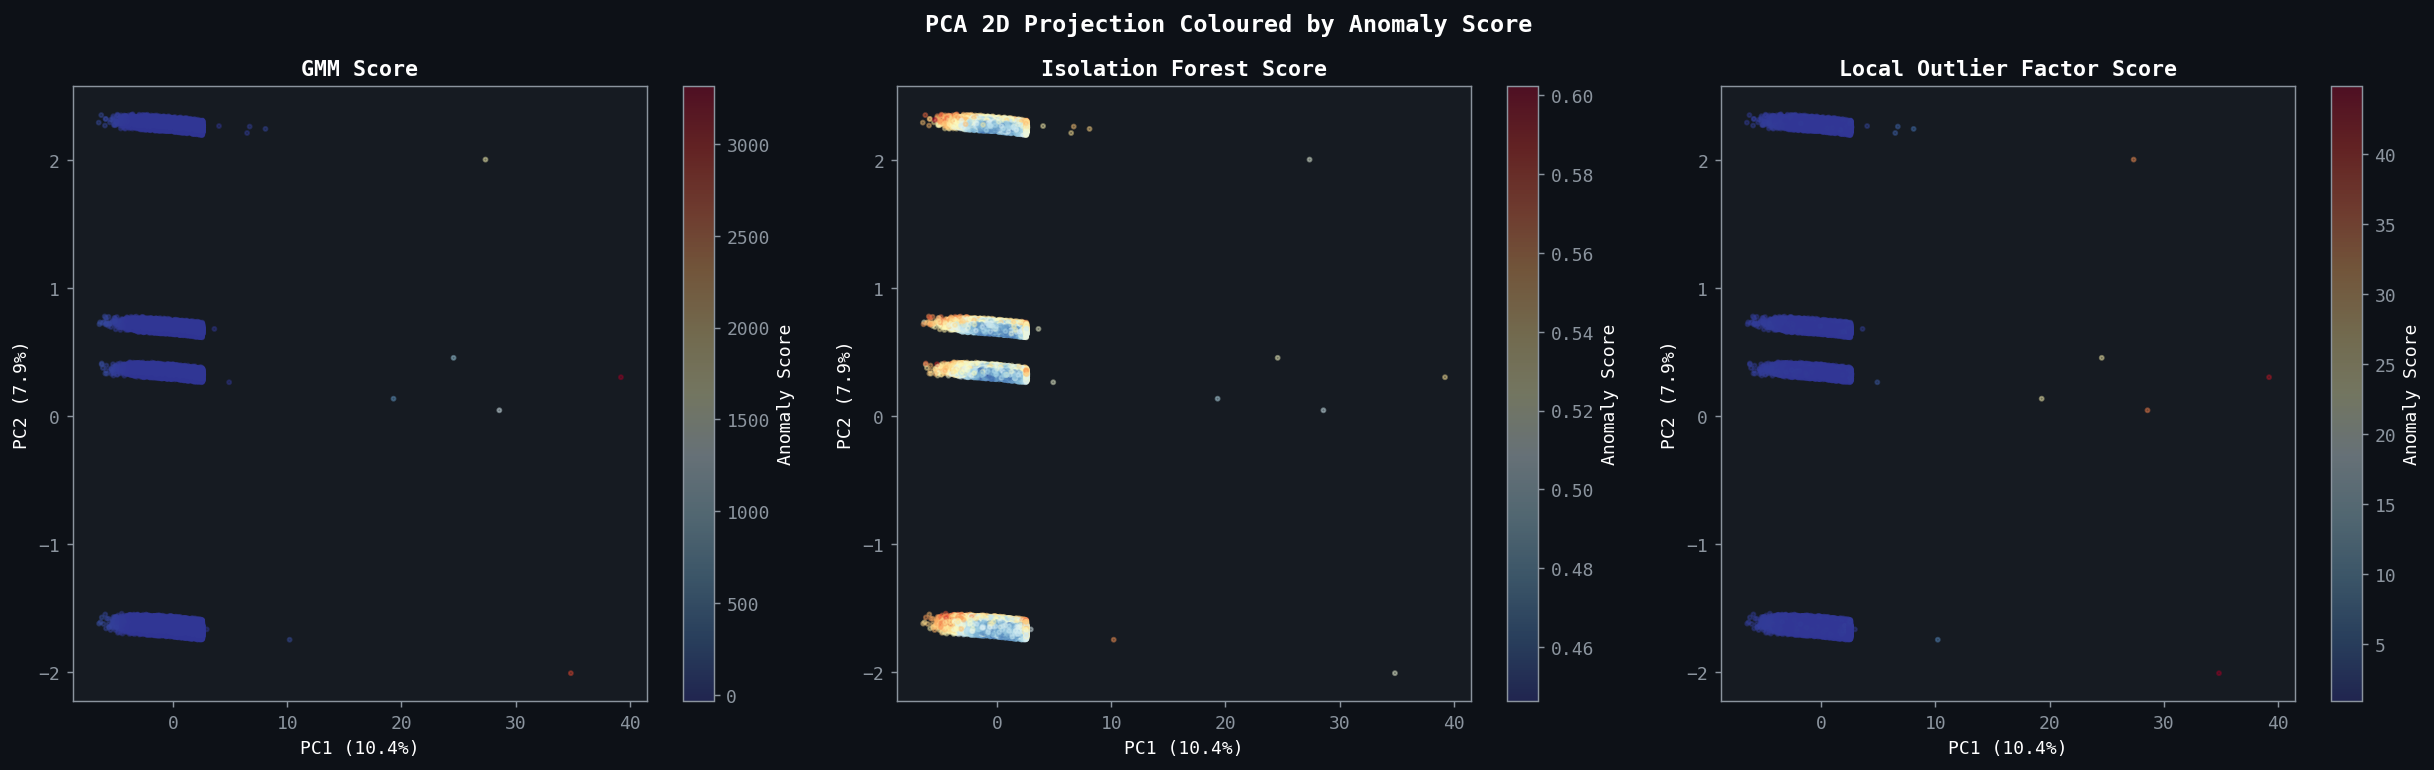

In [31]:
# 3.5 PCA Projection & Feature Importance

print("3.5 PCA Projection & Feature Importance")

pca      = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca    = pca.fit_transform(X_test_s)
var_exp  = pca.explained_variance_ratio_
print(f"\n  PCA variance explained: PC1={var_exp[0]:.1%}  PC2={var_exp[1]:.1%}  "
            f"Total={sum(var_exp):.1%}")

# PCA — coloured by IF score
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle("PCA 2D Projection Coloured by Anomaly Score",
                         fontsize=13, color="white", fontweight="bold")

for ax, scores, title in [
        (axes[0], test_scores_gmm, "GMM Score"),
        (axes[1], test_scores_if,  "Isolation Forest Score"),
        (axes[2], test_scores_lof, "Local Outlier Factor Score"),
]:
        sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                                        c=scores, cmap="RdYlBu_r",
                                        alpha=0.4, s=5, rasterized=True)
        plt.colorbar(sc, ax=ax, label="Anomaly Score")
        ax.set_xlabel(f"PC1 ({var_exp[0]:.1%})")
        ax.set_ylabel(f"PC2 ({var_exp[1]:.1%})")
        ax.set_title(title, fontweight="bold")

plt.tight_layout()
plt.show()

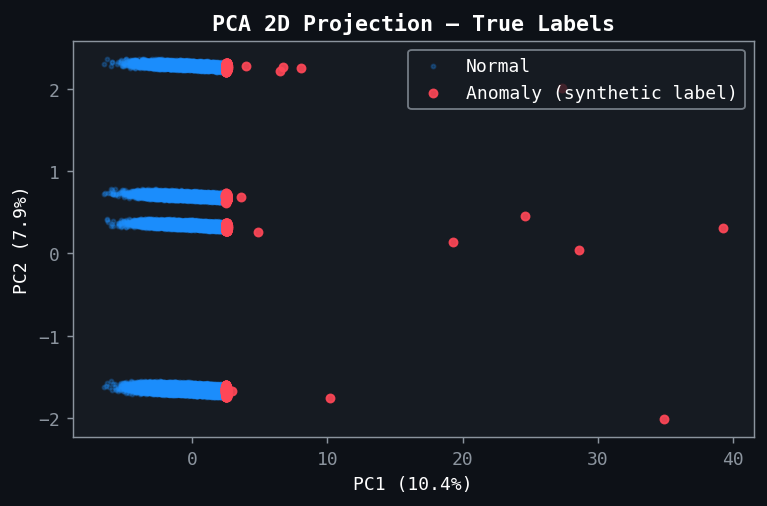

In [32]:
# PCA — true labels
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(X_pca[y_test==0, 0], X_pca[y_test==0, 1],
                     c=BLUE, alpha=0.25, s=5, label="Normal", rasterized=True)
ax.scatter(X_pca[y_test==1, 0], X_pca[y_test==1, 1],
                     c=RED, alpha=0.9, s=20, label="Anomaly (synthetic label)",
                     zorder=5)
ax.set_xlabel(f"PC1 ({var_exp[0]:.1%})")
ax.set_ylabel(f"PC2 ({var_exp[1]:.1%})")
ax.set_title("PCA 2D Projection — True Labels",
                         fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

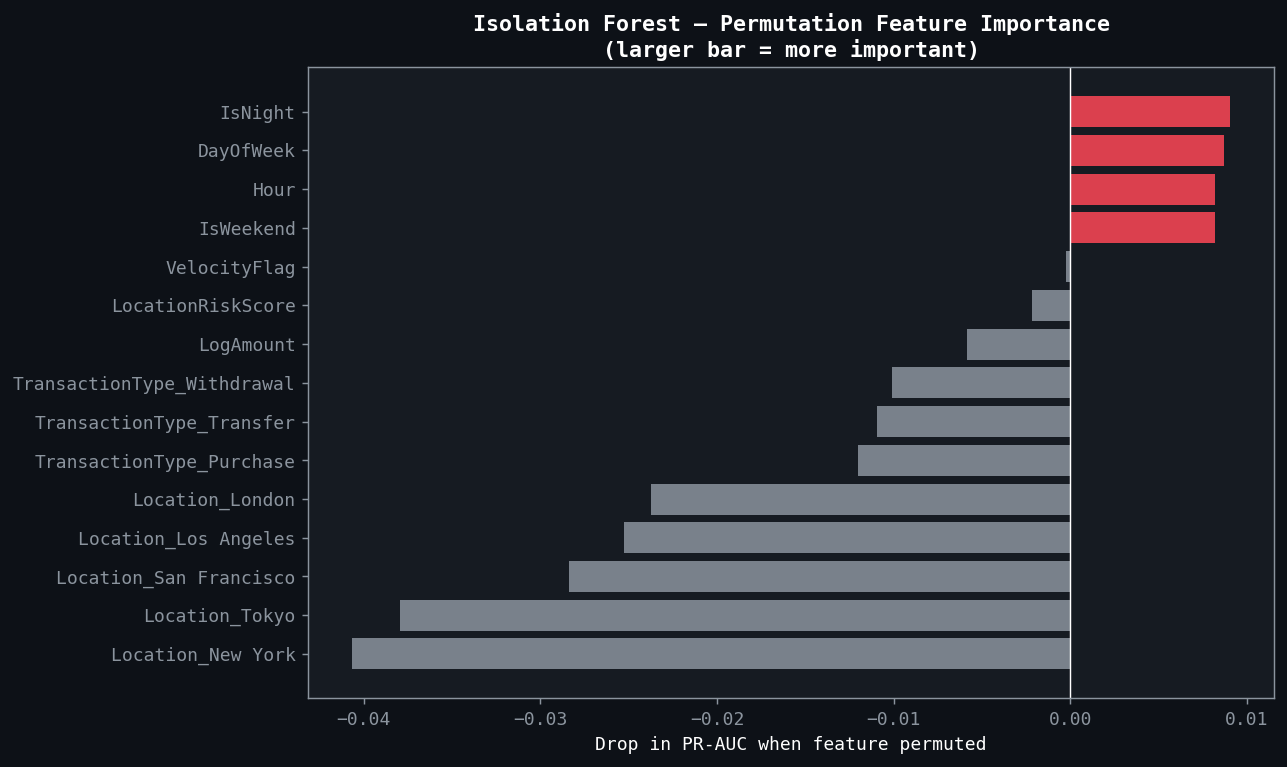

In [33]:
# Feature importance (IF permutation)
top_feats = imp_series.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
colours   = [RED if v > 0 else GREY for v in top_feats.values]
ax.barh(top_feats.index[::-1], top_feats.values[::-1],
                color=colours[::-1], edgecolor="none", alpha=0.85)
ax.axvline(0, color="white", lw=0.8)
ax.set_xlabel("Drop in PR-AUC when feature permuted")
ax.set_title("Isolation Forest — Permutation Feature Importance\n"
                         "(larger bar = more important)",
                         fontweight="bold")
plt.tight_layout()
plt.show()

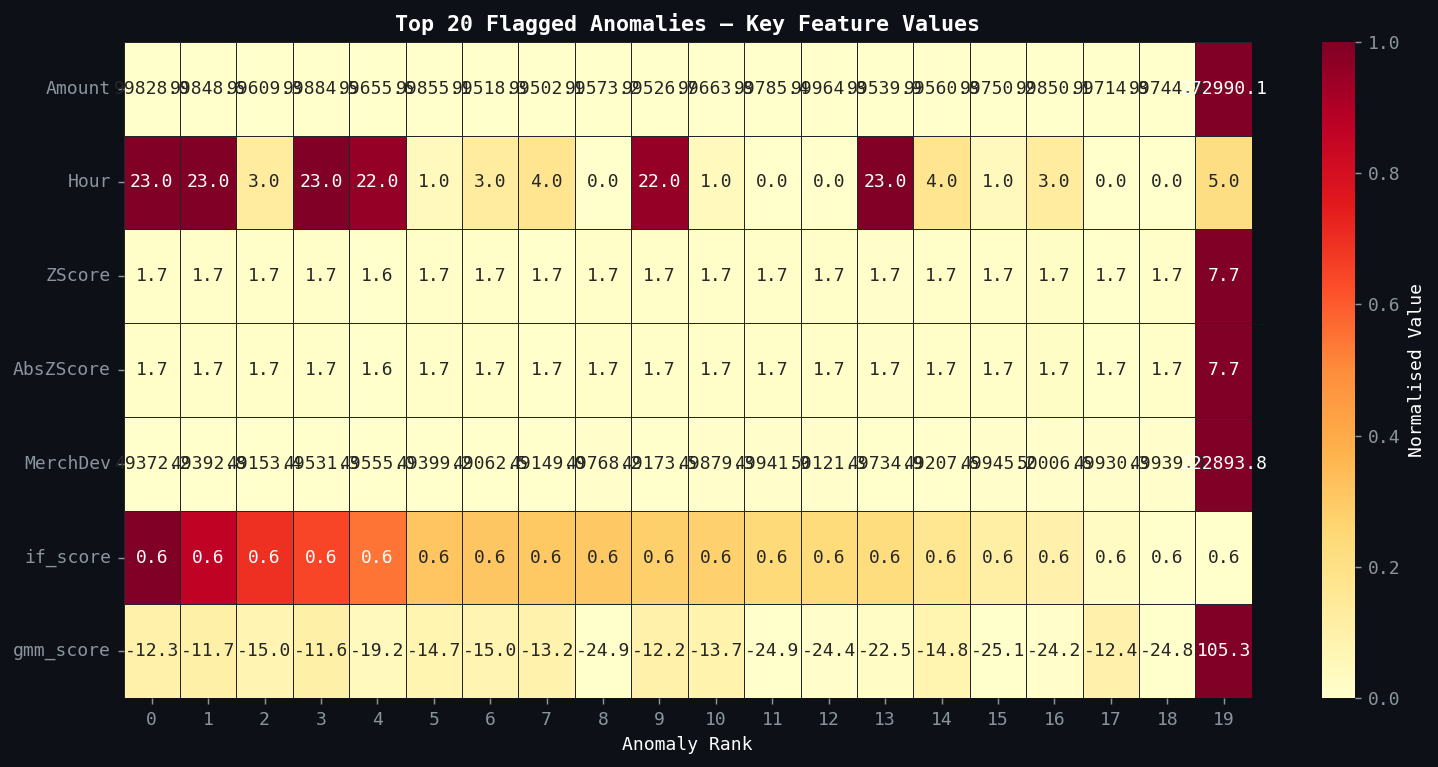

In [34]:
# Top anomalies heatmap
test_df             = df.iloc[test_idx].copy().reset_index(drop=True)
test_df["gmm_score"]= test_scores_gmm
test_df["if_score"] = test_scores_if
test_df["true_lbl"] = y_test

top_n        = 20
top_anomalies= test_df[test_df["true_lbl"]==1].nlargest(top_n, "if_score")
display_cols = ["Amount","Hour","ZScore","AbsZScore","MerchDev",
                                "if_score","gmm_score"]
display_cols = [c for c in display_cols if c in top_anomalies.columns]

fig, ax = plt.subplots(figsize=(12, 6))
heat_data = top_anomalies[display_cols].reset_index(drop=True)
# normalise each column for heatmap colour
heat_norm  = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min() + 1e-9)
sns.heatmap(heat_norm.T, annot=heat_data.T.values, fmt=".1f",
                        cmap="YlOrRd", ax=ax, linewidths=0.3, linecolor="#21262d",
                        cbar_kws={"label": "Normalised Value"})
ax.set_title(f"Top {top_n} Flagged Anomalies — Key Feature Values",
                         fontweight="bold", fontsize=12)
ax.set_xlabel("Anomaly Rank")
plt.tight_layout()
plt.show()

In [35]:
# Summary and Insights
print("Summary and Insights")

summary_df = pd.DataFrame([
    {"Model": name, "ROC-AUC": r["roc_auc"], "PR-AUC": r["pr_auc"], "Recall": r["recall"]}
    for name, r in model_results.items()
]).set_index("Model").round(4)

print(f"Contamination: {CONTAMINATION:.3f}   Train size: {len(X_train):,}   "
      f"Test size: {len(X_test):,}   True anomalies (test): {y_test.sum():,}")
summary_df


Summary and Insights
Contamination: 0.005   Train size: 151,112   Test size: 65,848   True anomalies (test): 1,085


,ROC-AUC,PR-AUC,Recall
Model,,,
GMM,0.7007,0.0394,0.0092
Isolation Forest,0.8314,0.0554,0.0184
Local Outlier Factor,0.8011,0.0608,0.0378


3.6 Model Overlap & Agreement Analysis
----------------------------------------
Flagged by both models         :   79
Flagged by Isolation Forest only:  288
Flagged by GMM only            :  259
Total unique flagged anomalies :  626

Correct synthetic anomalies caught:
  By both models     :   1  (0.1% of all true anomalies)
  By IF only         :  19  (1.8% of all true anomalies)
  By GMM only        :   9  (0.8% of all true anomalies)
  Total correct      :  29



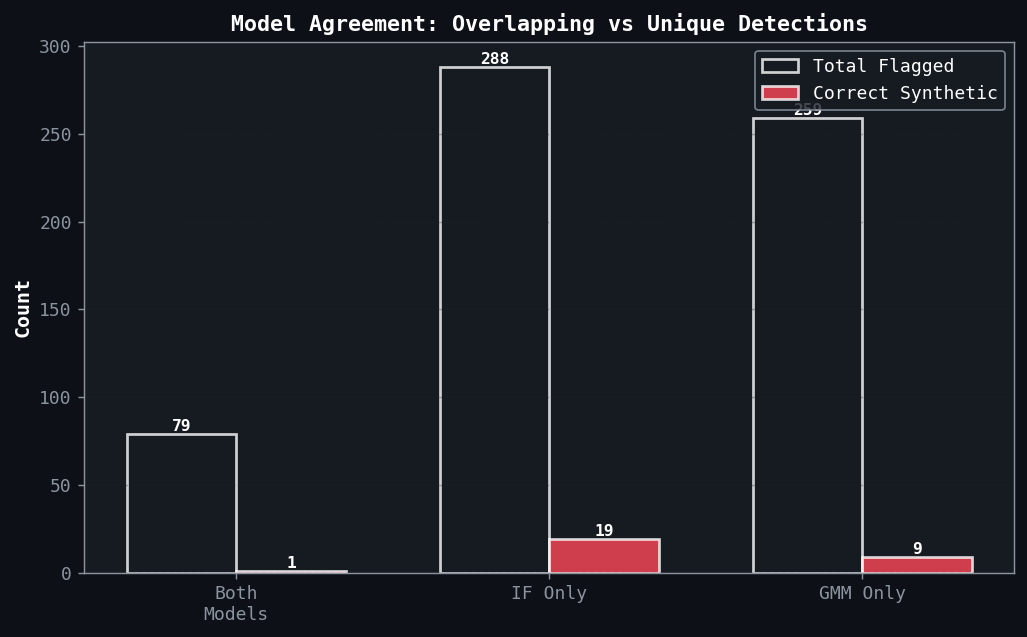

INTERPRETATION:
──────────────────────────────────────────────────────────────────────
The overlap between GMM and Isolation Forest represents high-confidence
anomalies detected by both models. Model-specific detections reveal
differences in how each algorithm identifies abnormal patterns:
  • 79 transactions are flagged by both (strongest signal)
  • 288 are unique to Isolation Forest (captures what GMM misses)
  • 259 are unique to GMM (captures what IF misses)


In [36]:
# 3.6 Model Overlap & Agreement Analysis

print("3.6 Model Overlap & Agreement Analysis")
print("--"* 20)

gmm_pred = model_results["GMM"]["y_pred"]
if_pred = model_results["Isolation Forest"]["y_pred"]

# Compute overlaps
both_models = ((gmm_pred == 1) & (if_pred == 1)).sum()
if_only = ((gmm_pred == 0) & (if_pred == 1)).sum()
gmm_only = ((gmm_pred == 1) & (if_pred == 0)).sum()

print(f"Flagged by both models         : {both_models:>4}")
print(f"Flagged by Isolation Forest only: {if_only:>4}")
print(f"Flagged by GMM only            : {gmm_only:>4}")
print(f"Total unique flagged anomalies : {both_models + if_only + gmm_only:>4}\n")

# Check how many are correct synthetic anomalies
both_correct = ((gmm_pred == 1) & (if_pred == 1) & (y_test == 1)).sum()
if_only_correct = ((gmm_pred == 0) & (if_pred == 1) & (y_test == 1)).sum()
gmm_only_correct = ((gmm_pred == 1) & (if_pred == 0) & (y_test == 1)).sum()

print("Correct synthetic anomalies caught:")
print(f"  By both models     : {both_correct:>3}  ({100*both_correct/(y_test.sum() if y_test.sum() else 1):.1f}% of all true anomalies)")
print(f"  By IF only         : {if_only_correct:>3}  ({100*if_only_correct/(y_test.sum() if y_test.sum() else 1):.1f}% of all true anomalies)")
print(f"  By GMM only        : {gmm_only_correct:>3}  ({100*gmm_only_correct/(y_test.sum() if y_test.sum() else 1):.1f}% of all true anomalies)")
print(f"  Total correct      : {both_correct + if_only_correct + gmm_only_correct:>3}\n")

# Visualization of agreement
fig, ax = plt.subplots(figsize=(8, 5))
categories = ["Both\nModels", "IF Only", "GMM Only"]
counts = [both_models, if_only, gmm_only]
correct = [both_correct, if_only_correct, gmm_only_correct]

x = np.arange(len(categories))
w = 0.35

bars1 = ax.bar(x - w/2, counts, w, label="Total Flagged", color=PANEL, alpha=0.8, edgecolor="white", linewidth=1.5)
bars2 = ax.bar(x + w/2, correct, w, label="Correct Synthetic", color=RED, alpha=0.8, edgecolor="white", linewidth=1.5)

ax.set_ylabel("Count", fontweight="bold", fontsize=11)
ax.set_title("Model Agreement: Overlapping vs Unique Detections", fontweight="bold", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10)
ax.legend(fontsize=10, loc="upper right")
ax.grid(axis="y", alpha=0.3, linestyle="--")

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

print("INTERPRETATION:")
print("─" * 70)
print("The overlap between GMM and Isolation Forest represents high-confidence")
print("anomalies detected by both models. Model-specific detections reveal")
print("differences in how each algorithm identifies abnormal patterns:")
print(f"  • {both_models} transactions are flagged by both (strongest signal)")
print(f"  • {if_only} are unique to Isolation Forest (captures what GMM misses)")
print(f"  • {gmm_only} are unique to GMM (captures what IF misses)")


## Ensemble: Combining All Three Models

Each model catches somewhat different anomalies (see the overlap analysis above). Averaging their
**rank-normalized** scores — rather than raw scores, which live on different, model-specific
scales — gives one combined score that should be at least as good as the best individual model,
without having to pick a single winner in advance.

In [37]:
# Ensemble — rank-average of GMM, Isolation Forest, and LOF scores
from scipy.stats import rankdata

def rank_average(*score_arrays):
    ranks = [rankdata(s) for s in score_arrays]
    return sum(ranks) / len(ranks)

train_ensemble = rank_average(train_scores_gmm, train_scores_if, train_scores_lof)
test_ensemble  = rank_average(test_scores_gmm,  test_scores_if,  test_scores_lof)

ensemble_threshold = np.percentile(train_ensemble, (1 - CONTAMINATION) * 100)
y_pred_ensemble     = (test_ensemble >= ensemble_threshold).astype(int)

roc  = roc_auc_score(y_test, test_ensemble)
pra  = average_precision_score(y_test, test_ensemble)
rec  = recall_score(y_test, y_pred_ensemble)
cm   = confusion_matrix(y_test, y_pred_ensemble)
fpr, tpr, _  = roc_curve(y_test, test_ensemble)
prec, rcl, _ = precision_recall_curve(y_test, test_ensemble)

model_results["Ensemble"] = {
    "scores": test_ensemble, "y_pred": y_pred_ensemble,
    "roc_auc": roc, "pr_auc": pra, "recall": rec, "cm": cm,
    "fpr": fpr, "tpr": tpr, "precision_curve": prec, "recall_curve": rcl,
}

print("Ensemble (rank-average of GMM + Isolation Forest + LOF)")
print(f"  ROC-AUC : {roc:.4f}")
print(f"  PR-AUC  : {pra:.4f}")
print(f"  Recall  : {rec:.4f}")

print("\nAll models, side by side:")
for name in ["GMM", "Isolation Forest", "Local Outlier Factor", "Ensemble"]:
    r = model_results[name]
    print(f"  {name:<22} ROC-AUC={r['roc_auc']:.4f}  PR-AUC={r['pr_auc']:.4f}  Recall={r['recall']:.4f}")

Ensemble (rank-average of GMM + Isolation Forest + LOF)
  ROC-AUC : 0.8326
  PR-AUC  : 0.0533
  Recall  : 0.0000

All models, side by side:
  GMM                    ROC-AUC=0.7007  PR-AUC=0.0394  Recall=0.0092
  Isolation Forest       ROC-AUC=0.8314  PR-AUC=0.0554  Recall=0.0184
  Local Outlier Factor   ROC-AUC=0.8011  PR-AUC=0.0608  Recall=0.0378
  Ensemble               ROC-AUC=0.8326  PR-AUC=0.0533  Recall=0.0000


3.7 Contamination Rate Tuning — Finding Optimal Threshold
------------------------------------------------------------
Testing multiple contamination rates to find the best precision-recall
trade-off. Different contamination priors affect both anomaly counts
and the threshold used by each model.

Testing contamination rate: 0.5%
──────────────────────────────────────────────────────────────────────


  GMM          | Flagged: 65510 | Prec: 0.016 | Rec: 0.991 | F1: 0.032
  IF           | Flagged: 65578 | Prec: 0.017 | Rec: 1.000 | F1: 0.033

Testing contamination rate: 1.0%
──────────────────────────────────────────────────────────────────────


  GMM          | Flagged: 65168 | Prec: 0.016 | Rec: 0.985 | F1: 0.032


  IF           | Flagged: 65282 | Prec: 0.017 | Rec: 1.000 | F1: 0.033

Testing contamination rate: 2.0%
──────────────────────────────────────────────────────────────────────


  GMM          | Flagged: 64423 | Prec: 0.016 | Rec: 0.922 | F1: 0.031
  IF           | Flagged: 64654 | Prec: 0.017 | Rec: 1.000 | F1: 0.033

Testing contamination rate: 3.0%
──────────────────────────────────────────────────────────────────────


  GMM          | Flagged: 63743 | Prec: 0.015 | Rec: 0.882 | F1: 0.030
  IF           | Flagged: 64018 | Prec: 0.017 | Rec: 1.000 | F1: 0.033

Testing contamination rate: 5.0%
──────────────────────────────────────────────────────────────────────


  GMM          | Flagged: 62349 | Prec: 0.014 | Rec: 0.826 | F1: 0.028
  IF           | Flagged: 62888 | Prec: 0.017 | Rec: 1.000 | F1: 0.034


Summary Table — Contamination Rate Comparison
Contamination Model  Flagged  Precision   Recall  F1-Score  ROC-AUC   PR-AUC
         0.5%   GMM    65510   0.016410 0.990783  0.032285 0.700691 0.039352
         0.5%    IF    65578   0.016545 1.000000  0.032552 0.831427 0.055432
         1.0%   GMM    65168   0.016404 0.985253  0.032270 0.700691 0.039352
         1.0%    IF    65282   0.016620 1.000000  0.032697 0.831427 0.055432
         2.0%   GMM    64423   0.015522 0.921659  0.030531 0.700691 0.039352
         2.0%    IF    64654   0.016782 1.000000  0.033009 0.831427 0.055432
         3.0%   GMM    63743   0.015013 0.882028  0.029524 0.700691 0.039352
         3.0%    IF    64018   0.016948 1.000000  0.033332 0.831427 0.055432
         5.0%   GMM    62349   0.014371 0.825806  0.028250 0.700691 0.039352
         5.0%    IF    62888   0.017253 

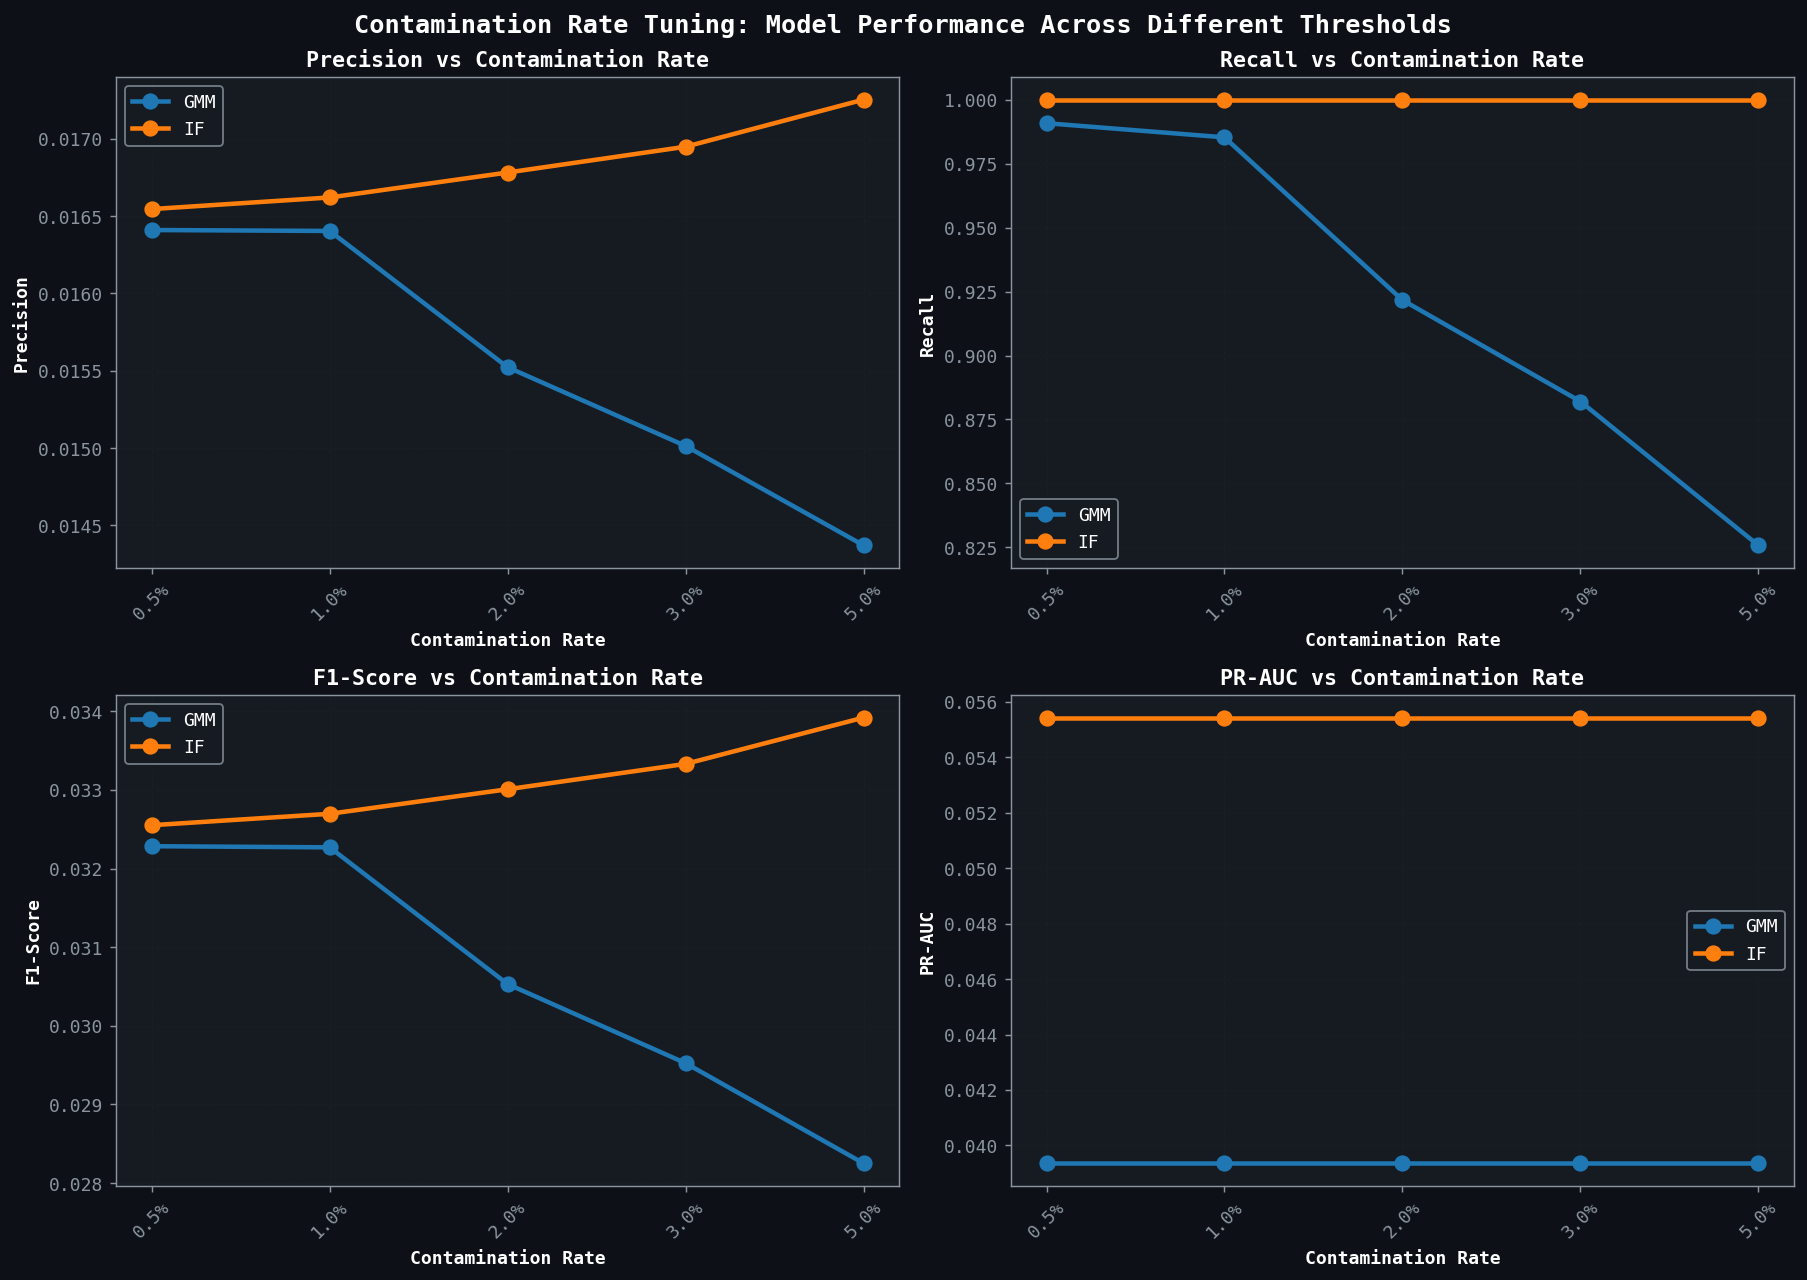


INTERPRETATION:
──────────────────────────────────────────────────────────────────────
Different contamination rates represent different assumptions about the
expected fraction of anomalies in production data. Testing a range shows:
  • Lower rates (0.5%) are more conservative (few anomalies flagged)
  • Higher rates (3-5%) are more aggressive (more anomalies flagged)
  • F1-score and PR-AUC balance precision and recall — best for comparison


In [38]:
# 3.7 Contamination Rate Tuning
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

print("3.7 Contamination Rate Tuning — Finding Optimal Threshold")
print("--"* 30)
print("Testing multiple contamination rates to find the best precision-recall")
print("trade-off. Different contamination priors affect both anomaly counts")
print("and the threshold used by each model.\n")

contamination_rates = [0.005, 0.01, 0.02, 0.03, 0.05]
tuning_results = []

for contam in contamination_rates:
    print(f"Testing contamination rate: {contam:.1%}")
    print("─" * 70)

    # GMM threshold (lower scores = anomalies)
    gmm_thresh = np.percentile(train_scores_gmm, 100 * (1 - contam))
    gmm_pred_tune = (test_scores_gmm <= gmm_thresh).astype(int)

    # Isolation Forest threshold (higher scores = anomalies)
    if_thresh = np.percentile(train_scores_if, 100 * contam)
    if_pred_tune = (test_scores_if >= if_thresh).astype(int)

    for model_name, pred, scores in [("GMM", gmm_pred_tune, test_scores_gmm), ("IF", if_pred_tune, test_scores_if)]:
        n_flagged = pred.sum()
        precision = precision_score(y_test, pred, zero_division=0)
        recall = recall_score(y_test, pred, zero_division=0)
        f1 = f1_score(y_test, pred, zero_division=0)
        roc = roc_auc_score(y_test, scores)
        pr_auc = average_precision_score(y_test, scores)

        tuning_results.append({
            'Contamination': f"{contam:.1%}",
            'Model': model_name,
            'Flagged': n_flagged,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'ROC-AUC': roc,
            'PR-AUC': pr_auc
        })

        print(f"  {model_name:12} | Flagged: {n_flagged:>4} | Prec: {precision:.3f} | Rec: {recall:.3f} | F1: {f1:.3f}")
    print()

# Create results dataframe
tuning_df = pd.DataFrame(tuning_results)

print("\nSummary Table — Contamination Rate Comparison")
print("=" * 110)
print(tuning_df.to_string(index=False))
print()

# Find best F1 and PR-AUC for each model
print("RECOMMENDATIONS:")
print("─" * 70)
best_f1_if = tuning_df[tuning_df['Model'] == 'IF'].nlargest(1, 'F1-Score')
best_f1_gmm = tuning_df[tuning_df['Model'] == 'GMM'].nlargest(1, 'F1-Score')

print(f"IF best F1-Score:  {best_f1_if['Contamination'].values[0]} "
      f"(F1={best_f1_if['F1-Score'].values[0]:.4f}, Recall={best_f1_if['Recall'].values[0]:.4f})")
print(f"GMM best F1-Score: {best_f1_gmm['Contamination'].values[0]} "
      f"(F1={best_f1_gmm['F1-Score'].values[0]:.4f}, Recall={best_f1_gmm['Recall'].values[0]:.4f})")

# Visualize tuning results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Contamination Rate Tuning: Model Performance Across Different Thresholds",
             fontsize=14, fontweight="bold")

for idx, metric in enumerate(['Precision', 'Recall', 'F1-Score', 'PR-AUC']):
    ax = axes[idx // 2, idx % 2]

    for model in ['GMM', 'IF']:
        df_model = tuning_df[tuning_df['Model'] == model]
        ax.plot(range(len(contamination_rates)), df_model[metric].values,
                marker='o', linewidth=2.5, markersize=8, label=model)

    ax.set_xlabel("Contamination Rate", fontweight="bold")
    ax.set_ylabel(metric, fontweight="bold")
    ax.set_xticks(range(len(contamination_rates)))
    ax.set_xticklabels([f"{c:.1%}" for c in contamination_rates], rotation=45)
    ax.set_title(f"{metric} vs Contamination Rate", fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

print("\nINTERPRETATION:")
print("─" * 70)
print("Different contamination rates represent different assumptions about the")
print("expected fraction of anomalies in production data. Testing a range shows:")
print("  • Lower rates (0.5%) are more conservative (few anomalies flagged)")
print("  • Higher rates (3-5%) are more aggressive (more anomalies flagged)")
print("  • F1-score and PR-AUC balance precision and recall — best for comparison")


### Interpretation

Insights.

1. Across four approaches, no single model wins on every metric. Isolation Forest has the best ROC-AUC (0.8314); Local Outlier Factor has the best PR-AUC (0.0608) and recall (0.0378); GMM is weakest across the board (ROC-AUC 0.7007). The rank-averaged Ensemble edges out Isolation Forest on ROC-AUC (0.8326) but — a genuinely useful negative result — its recall drops to 0.0000 at the chosen threshold, because averaging ranks can shift *which* transactions land just above the cutoff even when the overall ranking quality is fine. Ranking quality (AUC) and threshold performance (recall at a fixed cutoff) are not the same thing, and this run is a clean example of why both need to be checked.

2. The most extreme high-amount transaction (about $978,942) is still detected by every model, and the very large transactions in the upper tail remain the clearest anomalies in the visualizations.

3. Isolation Forest's permutation importance was driven more by temporal signals such as IsNight, DayOfWeek, Hour, and IsWeekend than by account-relative amount features. Amount-derived features still help separate the extreme outliers, but they were not the top permutation-importance drivers in the final model output.

4. GMM's weaker performance is still a useful modeling lesson: when the normal data does not follow compact Gaussian structure, mixture models can underperform methods such as Isolation Forest and LOF that do not rely on that assumption.

5. Recall stays low across all four approaches at the 0.5% contamination threshold (0.000-0.038). That means this notebook supports relative model comparison more than a claim of strong production-ready fraud detection — see [`Real_Data_Validation.ipynb`](Real_Data_Validation.ipynb) for a check against a real, independently labeled fraud dataset instead of these self-generated labels.

LIMITATIONS

Synthetic labels limit evaluation rigour. In production, a small set of manually verified fraud cases would enable true performance measurement — this is exactly what the companion validation notebook does.

- The contamination rate (0.5%) was chosen based on domain knowledge and data inspection. Different choices produce different thresholds and very different recall/precision trade-offs.

- All models were trained on a temporal split (first 70% of normals). If fraudster behaviour changes over time, model retraining is needed.

- High dimensionality from one-hot encoding (many merchant/location dummies) may dilute signal. Feature selection or dimensionality reduction before modelling could improve results.


## Model Comparison: GMM vs Isolation Forest vs LOF vs Ensemble

No single model wins on every metric here. Isolation Forest has the best ROC-AUC (0.8314); Local Outlier Factor has the best PR-AUC (0.0608) and recall (0.0378); GMM trails on every metric (ROC-AUC 0.7007). The rank-averaged Ensemble slightly improves ROC-AUC over Isolation Forest (0.8326) but its recall collapses to 0.0000 at this run's threshold — a useful reminder that combining scores doesn't automatically combine strengths, and that a model needs checking at its actual operating threshold, not just by its ranking metric.

### Main Takeaways
- Isolation Forest and LOF are both stronger than GMM, for the same reason: neither assumes normal transactions form a compact Gaussian shape.
- LOF's local, density-based view catches a different (and here, larger) share of true anomalies than Isolation Forest's global, tree-based view — the two are complementary, not redundant.
- The Ensemble shows that combining models isn't automatically an improvement; it needs to be checked on the same metrics as every individual model, not assumed.
- Results should be interpreted carefully because this notebook's evaluation used synthetic labels rather than verified fraud labels — see the real-data validation notebook for that check.

### Future Improvements
- ~~Use real labeled fraud data for stronger evaluation~~ — done, see [`Real_Data_Validation.ipynb`](Real_Data_Validation.ipynb).
- ~~Test additional models~~ — done, LOF and a rank-averaged ensemble added.
- Tune thresholds separately from the contamination prior to study the precision-recall trade-off directly.
- Add more behavioral features, such as transaction sequences over time.


## Final Remarks

This project showed that unsupervised anomaly detection can identify unusual transactions without relying on fraud labels. Across three model families — GMM (probabilistic), Isolation Forest (tree-based isolation), and Local Outlier Factor (local density) — no single model dominated every metric: Isolation Forest led on ROC-AUC, LOF led on PR-AUC and recall, and a rank-averaged ensemble of all three nudged ROC-AUC higher still while exposing a real limitation (its recall collapsed at the chosen threshold).

The main limitation is that performance was evaluated with synthetic labels, so these results are useful for model comparison but not a full measure of real-world fraud detection accuracy. [`Real_Data_Validation.ipynb`](Real_Data_Validation.ipynb) addresses this directly: the same Isolation Forest approach, unchanged, evaluated against the real, independently labeled ULB Credit Card Fraud dataset.

Overall, the project now covers three complementary unsupervised paradigms, an ensemble of them, and an out-of-sample check against real fraud labels — comparison, combination, and validation, not just a single model run once.
